# Elo Merchant Category Recommendation

## От знакомства с данными до финального прогноза

Нужно предсказать значение `target` для каждой карты из `test.csv`.

В исходных данных разные уровни детализации:

- в `train.csv` и `test.csv` одна строка соответствует одной карте;
- в `historical_transactions.csv` и `new_merchant_transactions.csv` хранятся отдельные покупки;
- в `merchants.csv` находятся характеристики продавцов;
- итоговый прогноз снова нужен на уровне `card_id`.

Я иду от простого решения к более сложному:

1. проверяю файлы и распределение target;
2. изучаю покупки и продавцов;
3. формулирую признаки по результатам EDA;
4. агрегирую транзакции до уровня карты;
5. сравниваю группы признаков;
6. обучаю baseline и настраиваю LightGBM, XGBoost и CatBoost;
7. проверяю target encoding и отдельную модель экстремального сегмента;
8. сравниваю одиночные модели и ансамбли;
9. выбираю финальный прогноз по OOF-результатам;
10. формирую итоговый файл `submission_final.csv`.

Ноутбук автономный: для запуска нужны только библиотеки и CSV-файлы соревнования.

## 0. Запуск

Ожидаемая структура папки:

```text
03_kaggle_feature_ensemble/
├── notebooks/
│   └── solution.ipynb
├── data/
│   ├── train.csv
│   ├── test.csv
│   ├── historical_transactions.csv
│   ├── new_merchant_transactions.csv
│   ├── merchants.csv
│   └── sample_submission.csv
├── submissions/
└── reports/
```

Также поддерживается стандартная папка Kaggle Input.

Промежуточные признаки, модели и результаты подбора параметров на диск не сохраняются.
При повторном запуске все расчёты выполняются заново.

## 1. Подготовка окружения

In [6]:
from pathlib import Path
import gc
import platform
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import sklearn
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

Сначала нахожу папку с данными и создаю каталоги только для итогового
`submission_final.csv` и скриншота результата. Промежуточные таблицы и модели
на диск не сохраняются: при новом запуске расчёт начинается заново.

In [7]:
PROJECT_DIR = Path.cwd().resolve()

for candidate in [PROJECT_DIR, PROJECT_DIR.parent]:
    if (
        (candidate / "data" / "train.csv").exists()
        or (candidate / "data" / "raw" / "train.csv").exists()
    ):
        PROJECT_DIR = candidate
        break

SUBMISSIONS_DIR = PROJECT_DIR / "submissions"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [SUBMISSIONS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

data_candidates = [
    PROJECT_DIR / "data",
    PROJECT_DIR / "data" / "raw",
    Path("/kaggle/input/elo-merchant-category-recommendation"),
    Path("/kaggle/input/competitions/elo-merchant-category-recommendation"),
]

DATA_DIR = next(
    (
        candidate
        for candidate in data_candidates
        if (candidate / "train.csv").exists()
    ),
    None,
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Не найден train.csv. Поместите файлы соревнования в data/ или data/raw/."
    )

print("Папка проекта:", PROJECT_DIR)
print("Папка с данными:", DATA_DIR)

Папка проекта: C:\Users\kosti\OneDrive\Документы\projects\projects_ml\projects\03_kaggle_feature_ensemble
Папка с данными: C:\Users\kosti\OneDrive\Документы\projects\projects_ml\projects\03_kaggle_feature_ensemble\data


Ниже находятся настройки полного запуска. Подбор параметров специально оставлен
достаточно большим: LightGBM и XGBoost получают по 60 trial, CatBoost — 40,
классификатор экстремального сегмента — 30.

In [8]:
SEED = 42
N_SPLITS = 5
CHUNK_SIZE = 750_000

LGB_OPTUNA_TRIALS = 60
XGB_OPTUNA_TRIALS = 60
CAT_OPTUNA_TRIALS = 40
OUTLIER_OPTUNA_TRIALS = 30

BOOTSTRAP_ITERATIONS = 2_000

Вывожу версии библиотек, чтобы результат можно было воспроизвести.


In [9]:
import lightgbm
import xgboost
import catboost
import optuna

versions = pd.Series(
    {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "lightgbm": lightgbm.__version__,
        "xgboost": xgboost.__version__,
        "catboost": catboost.__version__,
        "optuna": optuna.__version__,
        "platform": platform.platform(),
    },
    name="version",
)
display(versions.to_frame())


,version
python,3.10.9
numpy,1.26.0
pandas,2.1.4
scikit-learn,1.7.2
lightgbm,4.7.0
xgboost,3.2.0
catboost,1.2.10
optuna,4.9.0
platform,Windows-10-10.0.26200-SP0


## 2. Загрузка и первичная проверка данных

Сначала загружаю небольшие таблицы целиком. Большие таблицы транзакций пока не читаю:
до feature engineering нужно понять структуру данных и основные проблемы.


In [10]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
merchants = pd.read_csv(DATA_DIR / "merchants.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

overview = pd.DataFrame(
    {
        "table": ["train", "test", "merchants", "sample_submission"],
        "rows": [len(train), len(test), len(merchants), len(sample_submission)],
        "columns": [
            train.shape[1],
            test.shape[1],
            merchants.shape[1],
            sample_submission.shape[1],
        ],
        "memory_mb": [
            train.memory_usage(deep=True).sum() / 1024**2,
            test.memory_usage(deep=True).sum() / 1024**2,
            merchants.memory_usage(deep=True).sum() / 1024**2,
            sample_submission.memory_usage(deep=True).sum() / 1024**2,
        ],
    }
)
display(overview)


,table,rows,columns,memory_mb
0,train,201917,6,32.350716
1,test,123623,5,18.863464
2,merchants,334696,22,140.444153
3,sample_submission,123623,2,9.431808


Проверяю ключевые условия дальнейшего объединения: уникальность `card_id`,
наличие target только в train и совпадение порядка test с шаблоном submission.


In [11]:
display(train.head())
display(test.head())

checks = pd.DataFrame(
    {
        "check": [
            "train card_id unique",
            "test card_id unique",
            "target only in train",
            "sample_submission order equals test",
            "train/test input columns match",
        ],
        "value": [
            train["card_id"].is_unique,
            test["card_id"].is_unique,
            "target" in train.columns and "target" not in test.columns,
            sample_submission["card_id"].equals(test["card_id"]),
            set(train.columns) - {"target"} == set(test.columns),
        ],
    }
)
display(checks)

assert checks["value"].all(), "Одна из базовых проверок данных не пройдена."


,first_active_month,card_id,feature_1,feature_2,feature_3,target
0,2017-06,C_ID_92a2005557,5,2,1,-0.820283
1,2017-01,C_ID_3d0044924f,4,1,0,0.392913
2,2016-08,C_ID_d639edf6cd,2,2,0,0.688056
3,2017-09,C_ID_186d6a6901,4,3,0,0.142495
4,2017-11,C_ID_cdbd2c0db2,1,3,0,-0.159749


,first_active_month,card_id,feature_1,feature_2,feature_3
0,2017-04,C_ID_0ab67a22ab,3,3,1
1,2017-01,C_ID_130fd0cbdd,2,3,0
2,2017-08,C_ID_b709037bc5,5,1,1
3,2017-12,C_ID_d27d835a9f,2,1,0
4,2015-12,C_ID_2b5e3df5c2,5,1,1


,check,value
0,train card_id unique,True
1,test card_id unique,True
2,target only in train,True
3,sample_submission order equals test,True
4,train/test input columns match,True


Метрика соревнования — RMSE:

$$
\operatorname{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat y_i\right)^2
}.
$$

Крупные ошибки получают квадратичный штраф. Поэтому редкий экстремальный сегмент target
может заметно влиять на итог даже при небольшой доле таких карт.

## 3. EDA карт и целевой переменной

Проверяю типы, пропуски и количество уникальных значений.


In [12]:
card_audit = pd.DataFrame(
    {
        "train_dtype": train.dtypes.astype(str),
        "train_missing_rate": train.isna().mean(),
        "train_unique": train.nunique(dropna=False),
        "test_missing_rate": test.reindex(columns=train.columns).isna().mean(),
        "test_unique": test.reindex(columns=train.columns).nunique(dropna=False),
    }
)
display(card_audit)


,train_dtype,train_missing_rate,train_unique,test_missing_rate,test_unique
first_active_month,object,0.0,75,0.000008,76
card_id,object,0.0,201917,0.000000,123623
feature_1,int64,0.0,5,0.000000,5
feature_2,int64,0.0,3,0.000000,3
feature_3,int64,0.0,2,0.000000,2
target,float64,0.0,197110,1.000000,1


Преобразую `first_active_month` только для анализа. На этом этапе не строю итоговые признаки:
сначала проверяю диапазоны дат и различия train/test.


,train,test
min,2011-11-01 00:00:00,2011-11-01 00:00:00
max,2018-02-01 00:00:00,2018-01-01 00:00:00
missing,0,1


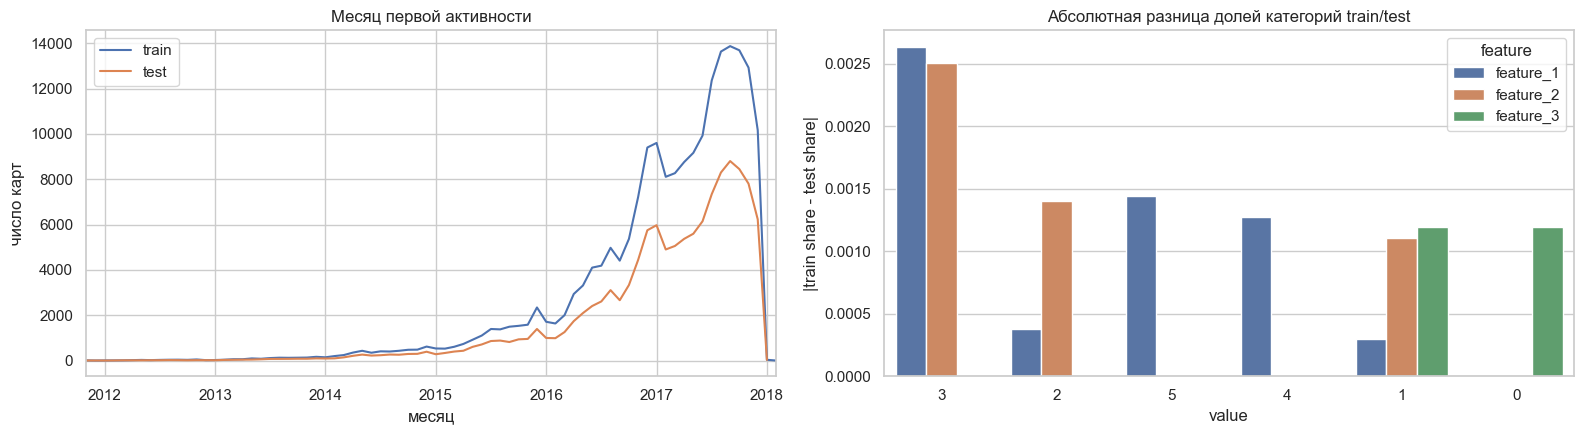

,train,test,abs_difference,feature,value
0,0.364372,0.361737,0.002636,feature_1,3
7,0.187384,0.184877,0.002507,feature_2,3
2,0.201197,0.202640,0.001444,feature_1,5
6,0.370642,0.372042,0.001400,feature_2,2
3,0.098481,0.099755,0.001274,feature_1,4
8,0.565569,0.564377,0.001192,feature_3,1
9,0.434431,0.435623,0.001192,feature_3,0
5,0.441974,0.443081,0.001107,feature_2,1
1,0.276336,0.275960,0.000376,feature_1,2
4,0.059614,0.059908,0.000294,feature_1,1


In [13]:
active_train = pd.to_datetime(
    train["first_active_month"],
    format="%Y-%m",
    errors="coerce",
)
active_test = pd.to_datetime(
    test["first_active_month"],
    format="%Y-%m",
    errors="coerce",
)

active_summary = pd.DataFrame(
    {
        "train": [
            active_train.min(),
            active_train.max(),
            int(active_train.isna().sum()),
        ],
        "test": [
            active_test.min(),
            active_test.max(),
            int(active_test.isna().sum()),
        ],
    },
    index=["min", "max", "missing"],
)
display(active_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

active_train.dt.to_period("M").value_counts().sort_index().plot(
    ax=axes[0],
    label="train",
)
active_test.dt.to_period("M").value_counts().sort_index().plot(
    ax=axes[0],
    label="test",
)
axes[0].set_title("Месяц первой активности")
axes[0].set_xlabel("месяц")
axes[0].set_ylabel("число карт")
axes[0].legend()

feature_shift_rows = []
for column in ["feature_1", "feature_2", "feature_3"]:
    train_share = train[column].value_counts(normalize=True).rename("train")
    test_share = test[column].value_counts(normalize=True).rename("test")
    comparison = pd.concat([train_share, test_share], axis=1).fillna(0)
    comparison["abs_difference"] = (comparison["train"] - comparison["test"]).abs()
    comparison["feature"] = column
    comparison["value"] = comparison.index.astype(str)
    feature_shift_rows.append(comparison.reset_index(drop=True))

feature_shift = pd.concat(feature_shift_rows, ignore_index=True)
sns.barplot(
    data=feature_shift,
    x="value",
    y="abs_difference",
    hue="feature",
    ax=axes[1],
)
axes[1].set_title("Абсолютная разница долей категорий train/test")
axes[1].set_ylabel("|train share - test share|")

plt.tight_layout()
plt.show()

display(feature_shift.sort_values("abs_difference", ascending=False).head(15))


Теперь рассматриваю target и отдельно изучаю левый хвост.


,target
count,201917.000000
mean,-0.393636
std,3.850500
min,-33.219281
0.1%,-33.219281
0.5%,-33.219281
1%,-33.219281
5%,-3.107836
50%,-0.023437
95%,2.702680


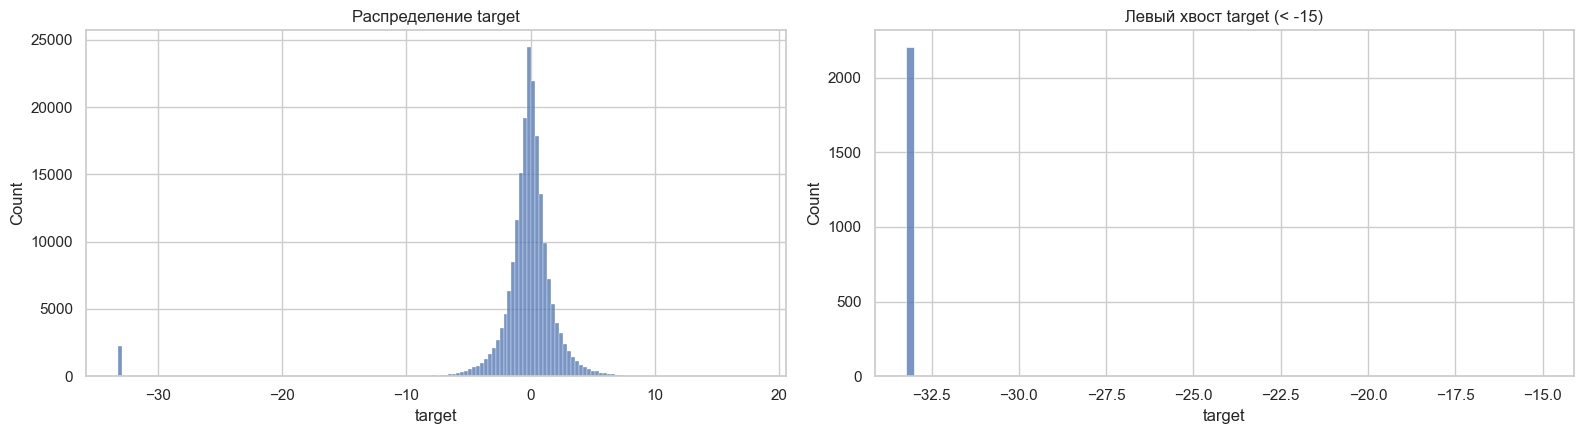

In [14]:
target_summary = train["target"].describe(
    percentiles=[0.001, 0.005, 0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999]
)
display(target_summary.to_frame("target"))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

sns.histplot(train["target"], bins=160, ax=axes[0])
axes[0].set_title("Распределение target")

left_tail = train.loc[train["target"] < -15, "target"]
sns.histplot(left_tail, bins=80, ax=axes[1])
axes[1].set_title("Левый хвост target (< -15)")

plt.tight_layout()
plt.show()


Порог экстремального сегмента не подбираю по RMSE. Сначала показываю фактические значения
в левом хвосте и разрыв между отдельным кластером и основной частью распределения.


In [15]:
left_tail_values = (
    train.loc[train["target"] < -20, "target"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)
display(left_tail_values.head(30))

sorted_unique_target = np.sort(train["target"].unique())
display(
    pd.Series(sorted_unique_target[:30], name="smallest_unique_target")
    .to_frame()
)

EXTREME_THRESHOLD = -30.0
extreme_mask = train["target"] < EXTREME_THRESHOLD

print("Выбранный технический порог:", EXTREME_THRESHOLD)
print("Карт в экстремальном сегменте:", int(extreme_mask.sum()))
print("Доля экстремального сегмента:", f"{extreme_mask.mean():.2%}")
print("Средний target сегмента:", train.loc[extreme_mask, "target"].mean())


,count
target,
-33.219281,2207


,smallest_unique_target
0,-33.219281
1,-17.608147
2,-17.492640
3,-17.441923
4,-17.189636
5,-15.835656
6,-15.553269
7,-15.400146
8,-15.291387
9,-15.103165


Выбранный технический порог: -30.0
Карт в экстремальном сегменте: 2207
Доля экстремального сегмента: 1.09%
Средний target сегмента: -33.21928094999999


Порог `-30` отделяет визуально заметный кластер около `-33.22`.
Он используется только для стратификации и отдельного диагностического классификатора,
а не подбирается как способ напрямую улучшить leaderboard.

Проверяю target по сочетаниям исходных категорий. Редкие группы исключаю из интерпретации,
чтобы не принимать случайное среднее нескольких карт за закономерность.


In [16]:
target_by_card_features = (
    train.groupby(["feature_1", "feature_2", "feature_3"])["target"]
    .agg(["count", "mean", "median", "std"])
    .query("count >= 100")
    .sort_values("mean")
)
display(target_by_card_features.head(15))
display(target_by_card_features.tail(15))


count      mean    median       std
feature_1 feature_2 feature_3                                     
3         3         1          24546 -0.569006 -0.022741  4.571546
5         1         1          24428 -0.561022 -0.015163  4.455991
1         3         0           2696 -0.543918 -0.157942  3.779823
4         1         0           9194 -0.413791 -0.027682  3.683565
2         1         0          24502 -0.409331  0.044959  4.105601
5         2         1          16197 -0.407664 -0.129116  3.594798
4         2         0           6923 -0.405038  0.000000  4.060115
          3         0           3768 -0.381644 -0.057494  3.679458
2         3         0           6826 -0.310319 -0.017809  3.564495
1         2         0           2833 -0.304027  0.000000  3.946988
2         2         0          24469 -0.302688 -0.047135  3.426653
3         2         1          24417 -0.296476 -0.043991  3.491006
          1         1          24610 -0.266980 -0.046852  3.311533
1         1         0           6508 -0.225825 -0.014864  2.957161

count      mean    median       std
feature_1 feature_2 feature_3                                     
3         3         1          24546 -0.569006 -0.022741  4.571546
5         1         1          24428 -0.561022 -0.015163  4.455991
1         3         0           2696 -0.543918 -0.157942  3.779823
4         1         0           9194 -0.413791 -0.027682  3.683565
2         1         0          24502 -0.409331  0.044959  4.105601
5         2         1          16197 -0.407664 -0.129116  3.594798
4         2         0           6923 -0.405038  0.000000  4.060115
          3         0           3768 -0.381644 -0.057494  3.679458
2         3         0           6826 -0.310319 -0.017809  3.564495
1         2         0           2833 -0.304027  0.000000  3.946988
2         2         0          24469 -0.302688 -0.047135  3.426653
3         2         1          24417 -0.296476 -0.043991  3.491006
          1         1          24610 -0.266980 -0.046852  3.311533
1         1         0           6508 -0.225825 -0.014864  2.957161

### Вывод после EDA карт

- исходных признаков мало, и они анонимизированы;
- в target есть небольшой отдельный экстремальный кластер;
- простого правила по `feature_1–3` для него не видно;
- одна дата первой активности в test отсутствует, поэтому пропуск нужно сохранить;
- основной сигнал, вероятно, находится в транзакционном поведении.

Следующий шаг — исследовать транзакции и таблицу продавцов до выбора агрегатов.

## 4. EDA транзакций и продавцов

`historical_transactions.csv` слишком велик для удобного EDA целиком.  
Первые `nrows` брать рискованно: файл может быть сгруппирован по картам.

Поэтому выбираю случайные `card_id` из train и test и затем читаю только их транзакции.


In [17]:
def load_transaction_sample(
    path: Path,
    card_ids: set[str],
    chunksize: int = CHUNK_SIZE,
) -> pd.DataFrame:
    usecols = [
        "authorized_flag",
        "card_id",
        "category_2",
        "category_3",
        "installments",
        "merchant_category_id",
        "merchant_id",
        "month_lag",
        "purchase_amount",
        "purchase_date",
    ]
    parts = []

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        chunksize=chunksize,
    ):
        selected = chunk.loc[chunk["card_id"].isin(card_ids)]
        if not selected.empty:
            parts.append(selected)

    return (
        pd.concat(parts, ignore_index=True)
        if parts
        else pd.DataFrame()
    )


sampled_train_ids = train["card_id"].sample(
    min(1_500, len(train)),
    random_state=SEED,
)
sampled_test_ids = test["card_id"].sample(
    min(500, len(test)),
    random_state=SEED,
)
eda_card_ids = set(
    pd.concat([sampled_train_ids, sampled_test_ids])
)

hist_sample = load_transaction_sample(
    DATA_DIR / "historical_transactions.csv",
    eda_card_ids,
)
new_sample = load_transaction_sample(
    DATA_DIR / "new_merchant_transactions.csv",
    eda_card_ids,
)

print("Выбрано карт:", len(eda_card_ids))
print("Historical rows:", len(hist_sample))
print("New rows:", len(new_sample))

Выбрано карт: 2000
Historical rows: 173468
New rows: 11973


Сравниваю период наблюдения, покрытие карт и продавцов.


In [18]:
for frame in [hist_sample, new_sample]:
    frame["purchase_date"] = pd.to_datetime(
        frame["purchase_date"],
        format="%Y-%m-%d %H:%M:%S",
        errors="raise",
    )

sample_overview = pd.DataFrame(
    {
        name: [
            len(frame),
            frame["card_id"].nunique(),
            frame["merchant_id"].nunique(),
            frame["purchase_date"].min(),
            frame["purchase_date"].max(),
            frame["month_lag"].min(),
            frame["month_lag"].max(),
            frame["authorized_flag"].eq("Y").mean(),
        ]
        for name, frame in {
            "historical": hist_sample,
            "new": new_sample,
        }.items()
    },
    index=[
        "rows",
        "cards",
        "merchants",
        "purchase_date min",
        "purchase_date max",
        "month_lag min",
        "month_lag max",
        "authorized share",
    ],
)
display(sample_overview)


,historical,new
rows,173468,11973
cards,2000,1791
merchants,35827,9078
purchase_date min,2017-01-01 00:15:24,2017-03-04 15:44:20
purchase_date max,2018-02-28 23:56:19,2018-04-30 23:25:30
month_lag min,-13,1
month_lag max,0,2
authorized share,0.911719,1.0


Проверяю пропуски категорий и специальные значения рассрочки.


In [19]:
missing_transactions = pd.DataFrame(
    {
        name: frame[
            ["category_2", "category_3", "merchant_id"]
        ].isna().mean()
        for name, frame in {
            "historical": hist_sample,
            "new": new_sample,
        }.items()
    }
)
display(missing_transactions)

installment_values = pd.DataFrame(
    {
        name: frame["installments"]
        .value_counts(dropna=False)
        .head(15)
        for name, frame in {
            "historical": hist_sample,
            "new": new_sample,
        }.items()
    }
).fillna(0)
display(installment_values)


,historical,new
category_2,0.081842,0.048526
category_3,0.005696,0.026142
merchant_id,0.004681,0.014032


,historical,new
installments,,
-1,988,313.0
0,94873,6077.0
1,67029,4772.0
2,3901,315.0
3,2960,235.0
4,1015,81.0
5,665,45.0
6,786,41.0
7,67,6.0


Для сравнения сумм использую одинаковое знаковое логарифмирование в обоих периодах:

$$
\operatorname{signed\_log}(x)=\operatorname{sign}(x)\log(1+|x|).
$$

В отличие от отдельного сдвига каждого распределения это преобразование сохраняет
общий масштаб и знак.


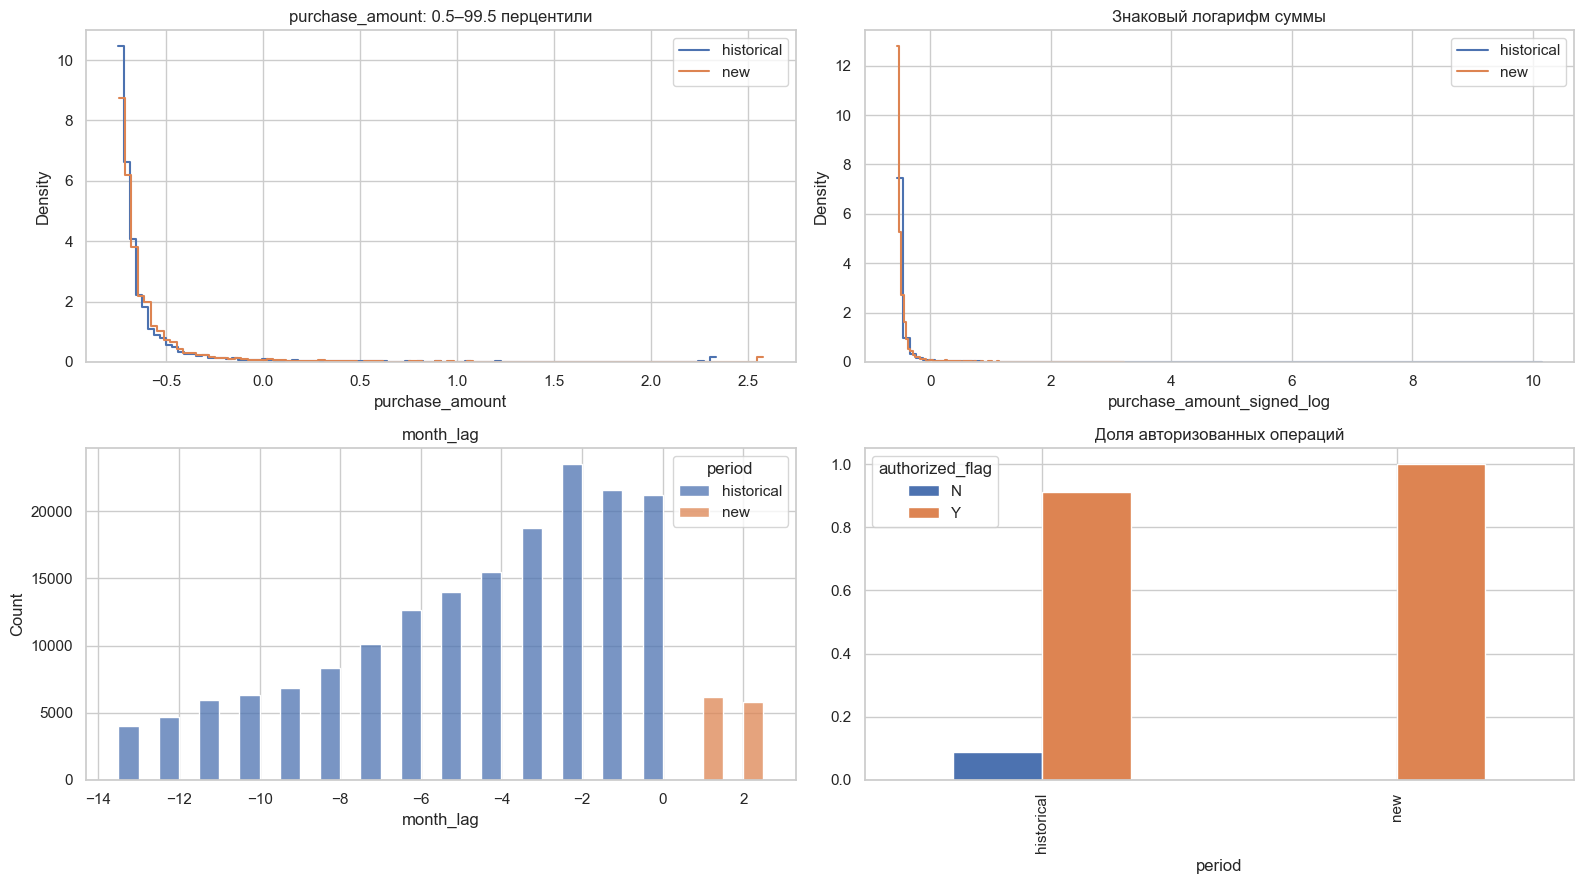

In [20]:
plot_frames = []
for name, frame in {"historical": hist_sample, "new": new_sample}.items():
    current = frame.copy()
    current["period"] = name
    current["purchase_amount_signed_log"] = (
        np.sign(current["purchase_amount"])
        * np.log1p(current["purchase_amount"].abs())
    )
    plot_frames.append(current)

transaction_plot = pd.concat(plot_frames, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for name, frame in transaction_plot.groupby("period"):
    upper = frame["purchase_amount"].quantile(0.995)
    lower = frame["purchase_amount"].quantile(0.005)

    sns.histplot(
        frame["purchase_amount"].clip(lower=lower, upper=upper),
        bins=100,
        stat="density",
        element="step",
        fill=False,
        label=name,
        ax=axes[0, 0],
    )
    sns.histplot(
        frame["purchase_amount_signed_log"],
        bins=100,
        stat="density",
        element="step",
        fill=False,
        label=name,
        ax=axes[0, 1],
    )

axes[0, 0].set_title("purchase_amount: 0.5–99.5 перцентили")
axes[0, 1].set_title("Знаковый логарифм суммы")
axes[0, 0].legend()
axes[0, 1].legend()

sns.histplot(
    data=transaction_plot,
    x="month_lag",
    hue="period",
    multiple="dodge",
    discrete=True,
    ax=axes[1, 0],
)
axes[1, 0].set_title("month_lag")

authorization = pd.crosstab(
    transaction_plot["period"],
    transaction_plot["authorized_flag"],
    normalize="index",
)
authorization.plot(
    kind="bar",
    ax=axes[1, 1],
    title="Доля авторизованных операций",
)

plt.tight_layout()
plt.show()


Агрегирую выборку до уровня карты, чтобы связать EDA с будущими признаками.


,count,mean,std,min,25%,50%,75%,max
transactions,2000.0,86.734000,109.208743,3.000000,26.000000,54.000000,108.000000,2143.000000
purchase_amount_sum,2000.0,-29.945543,596.088979,-1158.498740,-65.259724,-29.847048,-12.422729,25520.314610
purchase_amount_mean,2000.0,-0.162986,14.014641,-0.741768,-0.679051,-0.622887,-0.506676,622.446698
merchants,2000.0,32.809000,29.736319,1.000000,13.000000,24.000000,43.000000,345.000000
merchant_categories,2000.0,17.901500,11.123384,1.000000,9.000000,16.000000,24.000000,83.000000
authorized_rate,2000.0,0.891612,0.114161,0.181818,0.850000,0.926169,0.970888,1.000000
month_lag_min,2000.0,-7.799000,3.822683,-13.000000,-12.000000,-7.000000,-4.000000,-1.000000
month_lag_max,2000.0,-0.176000,0.695173,-10.000000,0.000000,0.000000,0.000000,0.000000


,count,mean,std,min,25%,50%,75%,max
transactions,1791.0,6.685092,6.598137,1.000000,2.000000,5.000000,9.000000,52.000000
purchase_amount_sum,1791.0,-3.707276,4.451203,-28.108217,-5.148804,-2.656883,-1.231746,37.613147
purchase_amount_mean,1791.0,-0.517719,0.761622,-0.745631,-0.695740,-0.647216,-0.546026,24.017535
merchants,1791.0,6.588498,6.553848,0.000000,2.000000,5.000000,8.000000,52.000000
merchant_categories,1791.0,5.297041,4.258017,1.000000,2.000000,4.000000,7.000000,31.000000
authorized_rate,1791.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
month_lag_min,1791.0,1.165271,0.371529,1.000000,1.000000,1.000000,1.000000,2.000000
month_lag_max,1791.0,1.815187,0.388254,1.000000,2.000000,2.000000,2.000000,2.000000


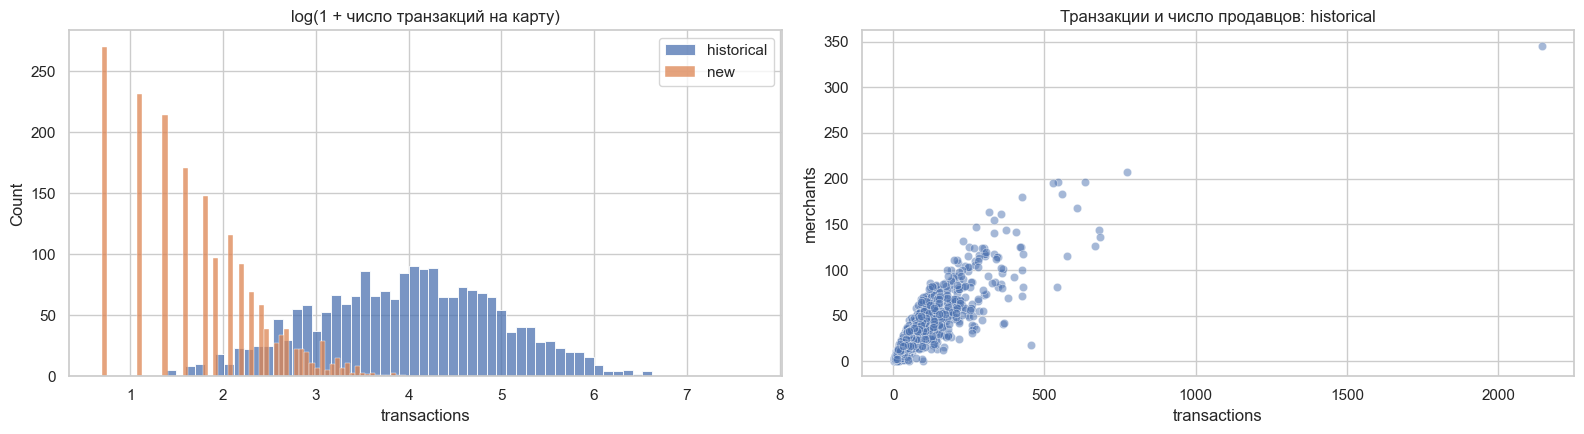

In [21]:
def card_level_sample_summary(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.groupby("card_id")
        .agg(
            transactions=("purchase_amount", "size"),
            purchase_amount_sum=("purchase_amount", "sum"),
            purchase_amount_mean=("purchase_amount", "mean"),
            merchants=("merchant_id", "nunique"),
            merchant_categories=("merchant_category_id", "nunique"),
            authorized_rate=("authorized_flag", lambda x: x.eq("Y").mean()),
            month_lag_min=("month_lag", "min"),
            month_lag_max=("month_lag", "max"),
        )
    )

hist_card_eda = card_level_sample_summary(hist_sample)
new_card_eda = card_level_sample_summary(new_sample)

display(hist_card_eda.describe().T)
display(new_card_eda.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

sns.histplot(
    np.log1p(hist_card_eda["transactions"]),
    bins=60,
    label="historical",
    ax=axes[0],
)
sns.histplot(
    np.log1p(new_card_eda["transactions"]),
    bins=60,
    label="new",
    ax=axes[0],
)
axes[0].set_title("log(1 + число транзакций на карту)")
axes[0].legend()

sns.scatterplot(
    data=hist_card_eda.sample(
        min(1_500, len(hist_card_eda)),
        random_state=SEED,
    ),
    x="transactions",
    y="merchants",
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title("Транзакции и число продавцов: historical")

plt.tight_layout()
plt.show()


Проверяю дубли продавцов и диапазоны числовых полей.


In [22]:
merchant_duplicates = merchants.loc[
    merchants["merchant_id"].duplicated(keep=False)
].sort_values("merchant_id")

print("Строк с повторяющимся merchant_id:", len(merchant_duplicates))
print(
    "Уникальных merchant_id с повторами:",
    merchant_duplicates["merchant_id"].nunique(),
)

merchant_numeric = merchants.select_dtypes(include=np.number).replace(
    [np.inf, -np.inf],
    np.nan,
)
display(
    merchant_numeric.describe(percentiles=[0.01, 0.5, 0.99]).T[
        ["count", "mean", "std", "min", "50%", "99%", "max"]
    ]
)


Строк с повторяющимся merchant_id: 104
Уникальных merchant_id с повторами: 41


,count,mean,std,min,50%,99%,max
merchant_group_id,334696.0,31028.736143,31623.043426,1.000000,19900.000000,109117.000000,1.125860e+05
merchant_category_id,334696.0,423.131663,252.898046,-1.000000,373.000000,884.000000,8.910000e+02
subsector_id,334696.0,25.116404,9.807371,-1.000000,27.000000,40.000000,4.100000e+01
numerical_1,334696.0,0.011476,1.098154,-0.057471,-0.057471,1.062914,1.837351e+02
numerical_2,334696.0,0.008103,1.070497,-0.057471,-0.057471,1.043084,1.820793e+02
avg_sales_lag3,334683.0,13.832993,2395.489999,-82.130000,1.000000,10.760000,8.518446e+05
avg_purchases_lag3,334693.0,1.590762,107.187059,0.333495,1.016667,7.333333,6.185133e+04
active_months_lag3,334696.0,2.994108,0.095247,1.000000,3.000000,3.000000,3.000000e+00
avg_sales_lag6,334683.0,21.650787,3947.108099,-82.130000,1.010000,18.701800,1.513959e+06
avg_purchases_lag6,334693.0,1.887568,97.862790,0.167045,1.026961,12.626111,5.607750e+04


In [23]:
# Выборка использовалась только для EDA.
del hist_sample, new_sample
gc.collect()


430

## 5. Что буду проверять дальше

После EDA получается следующий план.

### Признаки карты

- разобрать `first_active_month` на год, месяц и квартал;
- сохранить отдельный признак пропущенной даты;
- использовать сочетания `feature_1–3` как категории;
- не складывать анонимизированные категории между собой.

### Транзакции

- historical и new обрабатывать отдельно;
- значения рассрочки `-1` и `999` считать служебными;
- пропуски категорий отмечать отдельными флагами;
- вместо среднего кода категории считать доли значений;
- для суммы покупки использовать несколько статистик;
- одобренные и отклонённые операции описать отдельно;
- добавить показатели изменения активности по месяцам.

### Время

`month_lag` показывает положение покупки относительно опорного месяца карты.
Его можно восстановить прямо из даты покупки:

$$
\text{reference month index}
=
\text{purchase month index}
-
\text{month lag}.
$$

Так временные признаки не зависят от произвольно выбранной текущей даты.

### Продавцы

По повторяющимся `merchant_id` объединяю только числовые показатели.
Идентификаторы категории, города и подсектора не усредняю.

## 6. Построение признаков

Сначала создаю признаки самой карты, затем обрабатываю транзакции и свожу их
до одной строки на `card_id`.

In [24]:
train_base = train.drop(columns="target").copy()
test_base = test.copy()

for frame in [train_base, test_base]:
    active = pd.to_datetime(
        frame["first_active_month"],
        format="%Y-%m",
        errors="coerce",
    )

    frame["first_active_missing"] = active.isna().astype("int8")
    frame["first_active_year"] = active.dt.year
    frame["first_active_month_num"] = active.dt.month
    frame["first_active_quarter"] = active.dt.quarter
    frame["first_active_month_index"] = (
        active.dt.year * 12 + active.dt.month - 1
    )

    # Комбинации используются как идентификаторы групп.
    frame["feature_12_group"] = (
        frame["feature_1"] * 10 + frame["feature_2"]
    )
    frame["feature_13_group"] = (
        frame["feature_1"] * 10 + frame["feature_3"]
    )
    frame["feature_23_group"] = (
        frame["feature_2"] * 10 + frame["feature_3"]
    )
    frame["feature_123_group"] = (
        frame["feature_1"] * 100
        + frame["feature_2"] * 10
        + frame["feature_3"]
    )

    frame.drop(columns="first_active_month", inplace=True)

display(train_base.head())


,card_id,feature_1,feature_2,feature_3,first_active_missing,first_active_year,first_active_month_num,first_active_quarter,first_active_month_index,feature_12_group,feature_13_group,feature_23_group,feature_123_group
0,C_ID_92a2005557,5,2,1,0,2017,6,2,24209,52,51,21,521
1,C_ID_3d0044924f,4,1,0,0,2017,1,1,24204,41,40,10,410
2,C_ID_d639edf6cd,2,2,0,0,2016,8,3,24199,22,20,20,220
3,C_ID_186d6a6901,4,3,0,0,2017,9,3,24212,43,40,30,430
4,C_ID_cdbd2c0db2,1,3,0,0,2017,11,4,24214,13,10,30,130


### 6.2. Профили продавцов

По повторяющимся `merchant_id` объединяю только непрерывные и порядковые показатели.
Категориальные идентификаторы в среднее не включаются.


In [25]:
merchant_frame = merchants.copy()

range_mapping = {
    "A": 5,
    "B": 4,
    "C": 3,
    "D": 2,
    "E": 1,
}
for column in [
    "most_recent_sales_range",
    "most_recent_purchases_range",
]:
    merchant_frame[column] = merchant_frame[column].map(range_mapping)

merchant_frame["category_1_flag"] = (
    merchant_frame["category_1"] == "Y"
).astype("float32")
merchant_frame["category_4_flag"] = (
    merchant_frame["category_4"] == "Y"
).astype("float32")

merchant_numeric_columns = [
    "numerical_1",
    "numerical_2",
    "category_1_flag",
    "category_4_flag",
    "avg_sales_lag3",
    "avg_purchases_lag3",
    "avg_sales_lag6",
    "avg_purchases_lag6",
    "avg_sales_lag12",
    "avg_purchases_lag12",
    "active_months_lag3",
    "active_months_lag6",
    "active_months_lag12",
    "most_recent_sales_range",
    "most_recent_purchases_range",
]

merchant_frame[merchant_numeric_columns] = (
    merchant_frame[merchant_numeric_columns]
    .replace([np.inf, -np.inf], np.nan)
)

merchant_profile_by_id = (
    merchant_frame
    .groupby("merchant_id", sort=False)[merchant_numeric_columns]
    .mean()
)

merchant_maps = {
    column: merchant_profile_by_id[column]
    for column in merchant_numeric_columns
}

print("Продавцов в профиле:", len(merchant_profile_by_id))


Продавцов в профиле: 334633


### 6.3. Временные признаки транзакции

Одинаковые преобразования нужны для historical и new. Сначала разбираю
`purchase_date`, восстанавливаю опорный месяц карты и считаю положение покупки
внутри наблюдаемого периода.

In [26]:
def add_transaction_time_features(result: pd.DataFrame) -> pd.DataFrame:
    result["purchase_date"] = pd.to_datetime(
        result["purchase_date"],
        format="%Y-%m-%d %H:%M:%S",
        errors="raise",
    )
    result["purchase_year"] = result["purchase_date"].dt.year
    result["purchase_month"] = result["purchase_date"].dt.month
    result["purchase_weekday"] = result["purchase_date"].dt.weekday
    result["purchase_hour"] = result["purchase_date"].dt.hour
    result["purchase_weekend"] = (
        result["purchase_weekday"] >= 5
    ).astype("int8")

    result["purchase_month_index"] = (
        result["purchase_year"] * 12
        + result["purchase_month"]
        - 1
    )
    result["reference_month_index"] = (
        result["purchase_month_index"]
        - result["month_lag"]
    )

    reference_year = (
        result["reference_month_index"] // 12
    ).astype("Int64")
    reference_month = (
        result["reference_month_index"] % 12 + 1
    ).astype("Int64")

    reference_start = pd.to_datetime(
        {
            "year": reference_year,
            "month": reference_month,
            "day": 1,
        },
        errors="coerce",
    )
    reference_next_month = (
        reference_start + pd.offsets.MonthBegin(1)
    )
    result["days_before_reference_end"] = (
        reference_next_month - result["purchase_date"]
    ).dt.days

    return result


#### Категории и служебные флаги

Категориальные коды не усредняются как числа. Вместо этого создаются
индикаторы значений и отдельные признаки пропуска.


In [27]:
def add_transaction_category_features(
    result: pd.DataFrame,
) -> pd.DataFrame:
    result["authorized"] = (
        result["authorized_flag"] == "Y"
    ).astype("int8")
    result["category_1_flag"] = (
        result["category_1"] == "Y"
    ).astype("int8")

    result["category_2_missing"] = (
        result["category_2"].isna().astype("int8")
    )
    for value in range(1, 6):
        result[f"category_2_{value}_flag"] = (
            result["category_2"].eq(value).astype("int8")
        )

    category_3 = result["category_3"].astype("string")
    result["category_3_missing"] = (
        category_3.isna().astype("int8")
    )
    for value in ["A", "B", "C"]:
        result[f"category_3_{value}_flag"] = (
            category_3.eq(value)
            .fillna(False)
            .astype("int8")
        )

    return result


#### Рассрочка и сумма покупки

Значения `-1` и `999` не считаю настоящим количеством платежей. Отдельно отмечаю
нулевую и многоплатёжную рассрочку, а для суммы покупки добавляю модуль,
знаковый логарифм и несколько временных взаимодействий. Их польза позднее
проверяется в абляции.

In [28]:
def add_transaction_amount_features(
    result: pd.DataFrame,
) -> pd.DataFrame:
    result["installments_invalid"] = (
        result["installments"].isin([-1, 999]).astype("int8")
    )
    result["installments"] = result["installments"].replace(
        {-1: np.nan, 999: np.nan}
    )
    result["installments_zero"] = (
        result["installments"].fillna(0).eq(0).astype("int8")
    )
    result["installments_multi"] = (
        result["installments"].fillna(0).gt(1).astype("int8")
    )

    installment_denominator = result["installments"].where(
        result["installments"] > 0,
        1,
    )
    result["purchase_amount_per_installment"] = (
        result["purchase_amount"] / installment_denominator
    )
    result["purchase_amount_abs"] = (
        result["purchase_amount"].abs()
    )
    result["purchase_amount_signed_log"] = (
        np.sign(result["purchase_amount"])
        * np.log1p(result["purchase_amount"].abs())
    )

    result["amount_time_interaction"] = (
        result["purchase_amount"]
        * result["days_before_reference_end"]
    )
    result["amount_recency_ratio"] = (
        result["purchase_amount"]
        / (result["days_before_reference_end"].abs() + 1)
    )

    return result


#### Подготовка одного блока транзакций

На этом шаге объединяются временные, категориальные и денежные признаки,
после чего к покупке присоединяются характеристики продавца.

In [29]:
def prepare_transaction_block(block: pd.DataFrame) -> pd.DataFrame:
    result = block.copy()
    result = add_transaction_time_features(result)
    result = add_transaction_category_features(result)
    result = add_transaction_amount_features(result)

    for column, mapping in merchant_maps.items():
        result[f"merchant_{column}"] = (
            result["merchant_id"].map(mapping)
        )

    return result


### 6.4. Изменение активности по месяцам

Одних общих средних недостаточно: две карты могут иметь одинаковую сумму покупок,
но совершенно разную динамику. Поэтому отдельно считаю, как менялись число операций,
сумма и количество продавцов от месяца к месяцу.

In [30]:
def monthly_card_features(
    block: pd.DataFrame,
    prefix: str,
) -> pd.DataFrame:
    monthly = (
        block
        .groupby(["card_id", "month_lag"], sort=False)
        .agg(
            transaction_count=("purchase_amount", "size"),
            purchase_amount_sum=("purchase_amount", "sum"),
            purchase_amount_mean=("purchase_amount", "mean"),
            merchant_count=("merchant_id", "nunique"),
            authorized_rate=("authorized", "mean"),
        )
        .reset_index()
    )

    result = monthly.groupby("card_id", sort=False).agg(
        monthly_active_months=("month_lag", "nunique"),
        monthly_transaction_count_mean=("transaction_count", "mean"),
        monthly_transaction_count_std=("transaction_count", "std"),
        monthly_transaction_count_max=("transaction_count", "max"),
        monthly_purchase_amount_sum_mean=("purchase_amount_sum", "mean"),
        monthly_purchase_amount_sum_std=("purchase_amount_sum", "std"),
        monthly_purchase_amount_sum_min=("purchase_amount_sum", "min"),
        monthly_purchase_amount_sum_max=("purchase_amount_sum", "max"),
        monthly_purchase_amount_mean_mean=("purchase_amount_mean", "mean"),
        monthly_purchase_amount_mean_std=("purchase_amount_mean", "std"),
        monthly_merchant_count_mean=("merchant_count", "mean"),
        monthly_merchant_count_std=("merchant_count", "std"),
        monthly_authorized_rate_mean=("authorized_rate", "mean"),
        monthly_authorized_rate_std=("authorized_rate", "std"),
    )
    result.columns = [
        f"{prefix}_{column}"
        for column in result.columns
    ]
    return result.reset_index()


### 6.5. Агрегация до уровня карты

Для каждой карты считаю количество и сумму покупок, разброс, крайние значения,
разнообразие продавцов и категорий, а также отдельные показатели одобренных
и отклонённых операций.

In [31]:
def transaction_aggregation_spec() -> dict:
    aggregations = {
        "purchase_amount": [
            "count",
            "sum",
            "mean",
            "std",
            "min",
            "max",
            "median",
            "skew",
        ],
        "purchase_amount_abs": ["sum", "mean", "std", "max"],
        "purchase_amount_signed_log": ["mean", "std", "min", "max"],
        "installments": ["mean", "std", "min", "max", "sum"],
        "month_lag": ["mean", "std", "min", "max", "nunique"],
        "days_before_reference_end": ["mean", "std", "min", "max"],
        "reference_month_index": ["median", "min", "max", "nunique"],
        "purchase_year": ["min", "max", "nunique"],
        "purchase_month": ["mean", "std", "nunique"],
        "purchase_weekday": ["mean", "std", "nunique"],
        "purchase_hour": ["mean", "std", "nunique"],
        "purchase_weekend": "mean",
        "authorized": "mean",
        "category_1_flag": "mean",
        "category_2_missing": "mean",
        "category_3_missing": "mean",
        "installments_invalid": "mean",
        "installments_zero": "mean",
        "installments_multi": "mean",
        "merchant_category_id": "nunique",
        "subsector_id": "nunique",
        "city_id": "nunique",
        "state_id": "nunique",
        "merchant_id": "nunique",
        "amount_time_interaction": ["mean", "std", "min", "max"],
        "amount_recency_ratio": ["mean", "std", "min", "max"],
    }

    for value in range(1, 6):
        aggregations[f"category_2_{value}_flag"] = "mean"
    for value in ["A", "B", "C"]:
        aggregations[f"category_3_{value}_flag"] = "mean"

    return aggregations


In [32]:
def aggregate_complete_cards(
    block: pd.DataFrame,
    prefix: str,
) -> pd.DataFrame:
    aggregations = transaction_aggregation_spec()

    merchant_columns = [
        column
        for column in block.columns
        if column.startswith("merchant_")
        and column not in {
            "merchant_id",
            "merchant_category_id",
        }
    ]
    for column in merchant_columns:
        aggregations[column] = ["mean", "std"]

    result = block.groupby("card_id", sort=False).agg(aggregations)
    result.columns = [
        f"{prefix}_{column}_"
        f"{function if isinstance(function, str) else function.__name__}"
        for column, function in result.columns.to_flat_index()
    ]
    result = result.reset_index()

    for authorization, label in [
        (1, "authorized"),
        (0, "unauthorized"),
    ]:
        subset = block.loc[
            block["authorized"] == authorization
        ]
        statistics = (
            subset
            .groupby("card_id", sort=False)["purchase_amount"]
            .agg(["count", "sum", "mean"])
        )
        statistics.columns = [
            f"{prefix}_{label}_purchase_amount_{stat}"
            for stat in statistics.columns
        ]
        result = result.merge(
            statistics,
            left_on="card_id",
            right_index=True,
            how="left",
            validate="one_to_one",
        )

    result = result.merge(
        monthly_card_features(block, prefix),
        on="card_id",
        how="left",
        validate="one_to_one",
    )

    result[f"{prefix}_active_span_days"] = (
        result[f"{prefix}_days_before_reference_end_max"]
        - result[f"{prefix}_days_before_reference_end_min"]
    ).abs()
    result[f"{prefix}_transactions_per_active_day"] = (
        result[f"{prefix}_purchase_amount_count"]
        / (result[f"{prefix}_active_span_days"] + 1)
    )

    return result


### 6.6. Чтение больших файлов

Последнюю карту каждого чанка переношу в следующий чанк. Благодаря этому вся история
карты агрегируется целиком, а медиана, стандартное отклонение и число уникальных
значений не искажаются на границе частей файла.

In [33]:
def transaction_read_options():
    usecols = [
        "authorized_flag",
        "card_id",
        "city_id",
        "category_1",
        "category_2",
        "category_3",
        "installments",
        "merchant_category_id",
        "merchant_id",
        "month_lag",
        "purchase_amount",
        "purchase_date",
        "state_id",
        "subsector_id",
    ]
    dtypes = {
        "authorized_flag": "category",
        "card_id": "string",
        "city_id": "int16",
        "category_1": "category",
        "category_2": "float32",
        "category_3": "category",
        "installments": "int16",
        "merchant_category_id": "int32",
        "merchant_id": "string",
        "month_lag": "int16",
        "purchase_amount": "float32",
        "state_id": "int16",
        "subsector_id": "int16",
    }
    return usecols, dtypes


In [34]:
def aggregate_transaction_file(
    path: Path,
    prefix: str,
    chunksize: int = CHUNK_SIZE,
) -> pd.DataFrame:
    usecols, dtypes = transaction_read_options()

    parts = []
    carry = None
    finalized_cards = set()

    reader = pd.read_csv(
        path,
        usecols=usecols,
        dtype=dtypes,
        chunksize=chunksize,
    )

    for chunk_number, raw_chunk in enumerate(reader, start=1):
        chunk = (
            raw_chunk
            if carry is None
            else pd.concat([carry, raw_chunk], ignore_index=True)
        )

        last_card = chunk["card_id"].iloc[-1]
        complete = chunk.loc[
            chunk["card_id"] != last_card
        ]
        carry = chunk.loc[
            chunk["card_id"] == last_card
        ].copy()

        if not complete.empty:
            complete_ids = set(
                complete["card_id"].astype(str).unique()
            )
            repeated = complete_ids.intersection(finalized_cards)
            if repeated:
                example = next(iter(repeated))
                raise ValueError(
                    f"{path.name} не сгруппирован по card_id: "
                    f"карта {example} появилась повторно."
                )
            finalized_cards.update(complete_ids)

            prepared = prepare_transaction_block(complete)
            parts.append(
                aggregate_complete_cards(prepared, prefix)
            )

        print(f"{prefix}: обработан чанк {chunk_number}")

    if carry is not None and not carry.empty:
        carry_id = str(carry["card_id"].iloc[0])
        if carry_id in finalized_cards:
            raise ValueError(
                f"Карта {carry_id} появилась после завершения её блока."
            )

        prepared = prepare_transaction_block(carry)
        parts.append(
            aggregate_complete_cards(prepared, prefix)
        )

    if not parts:
        return pd.DataFrame(columns=["card_id"])

    result = pd.concat(parts, ignore_index=True)

    if not result["card_id"].is_unique:
        raise AssertionError(
            f"После агрегации {prefix} card_id должен быть уникальным."
        )

    return result


### 6.7. Изменение поведения между периодами

После раздельной агрегации historical и new добавляю разности и отношения:
как изменились число покупок, средняя сумма, разнообразие продавцов
и помесячная активность.

In [35]:
def add_cross_period_features(
    features: pd.DataFrame,
) -> pd.DataFrame:
    result = features.copy()

    basic_pairs = {
        "transaction_count_ratio": "purchase_amount_count",
        "purchase_amount_sum_ratio": "purchase_amount_sum",
        "merchant_diversity_ratio": "merchant_id_nunique",
    }
    for feature_name, suffix in basic_pairs.items():
        historical = result[f"hist_{suffix}"].fillna(0)
        new = result[f"new_{suffix}"].fillna(0)
        result[f"cross_basic_{feature_name}"] = (
            new / (historical.abs() + 1)
        )

    for suffix in [
        "purchase_amount_mean",
        "purchase_amount_std",
        "active_span_days",
        "transactions_per_active_day",
        "authorized_mean",
    ]:
        hist_column = f"hist_{suffix}"
        new_column = f"new_{suffix}"
        result[f"cross_basic_new_minus_hist_{suffix}"] = (
            result[new_column] - result[hist_column]
        )
        result[f"cross_basic_new_to_hist_{suffix}_ratio"] = (
            result[new_column]
            / (result[hist_column].abs() + 1)
        )

    for suffix in [
        "monthly_active_months",
        "monthly_transaction_count_mean",
        "monthly_purchase_amount_sum_mean",
        "monthly_authorized_rate_mean",
    ]:
        hist_column = f"hist_{suffix}"
        new_column = f"new_{suffix}"
        result[f"cross_monthly_new_minus_hist_{suffix}"] = (
            result[new_column] - result[hist_column]
        )
        result[f"cross_monthly_new_to_hist_{suffix}_ratio"] = (
            result[new_column]
            / (result[hist_column].abs() + 1)
        )

    for suffix in [
        "amount_time_interaction_mean",
        "amount_recency_ratio_mean",
    ]:
        hist_column = f"hist_{suffix}"
        new_column = f"new_{suffix}"
        result[f"cross_experimental_new_minus_hist_{suffix}"] = (
            result[new_column] - result[hist_column]
        )

    return result


### 6.8. Полная таблица признаков

Historical и new читаются по одному разу, агрегируются отдельно и затем
объединяются с таблицами карт.

#### Агрегация двух периодов

Сначала отдельно обрабатываю historical и new, затем объединяю их по `card_id`.

In [36]:
historical_features = aggregate_transaction_file(
    DATA_DIR / "historical_transactions.csv",
    prefix="hist",
)
new_features = aggregate_transaction_file(
    DATA_DIR / "new_merchant_transactions.csv",
    prefix="new",
)

transaction_features = historical_features.merge(
    new_features,
    on="card_id",
    how="outer",
    validate="one_to_one",
)
transaction_features = add_cross_period_features(
    transaction_features
).set_index("card_id")

full_train_features = train_base.join(
    transaction_features,
    on="card_id",
    how="left",
)
full_test_features = test_base.join(
    transaction_features,
    on="card_id",
    how="left",
)

hist: обработан чанк 1
hist: обработан чанк 2
hist: обработан чанк 3
hist: обработан чанк 4
hist: обработан чанк 5
hist: обработан чанк 6
hist: обработан чанк 7
hist: обработан чанк 8
hist: обработан чанк 9
hist: обработан чанк 10
hist: обработан чанк 11
hist: обработан чанк 12
hist: обработан чанк 13
hist: обработан чанк 14
hist: обработан чанк 15
hist: обработан чанк 16
hist: обработан чанк 17
hist: обработан чанк 18
hist: обработан чанк 19
hist: обработан чанк 20
hist: обработан чанк 21
hist: обработан чанк 22
hist: обработан чанк 23
hist: обработан чанк 24
hist: обработан чанк 25
hist: обработан чанк 26
hist: обработан чанк 27
hist: обработан чанк 28
hist: обработан чанк 29
hist: обработан чанк 30
hist: обработан чанк 31
hist: обработан чанк 32
hist: обработан чанк 33
hist: обработан чанк 34
hist: обработан чанк 35
hist: обработан чанк 36
hist: обработан чанк 37
hist: обработан чанк 38
hist: обработан чанк 39
new: обработан чанк 1
new: обработан чанк 2
new: обработан чанк 3


#### Нормировка активности на возраст карты

После объединения транзакций с базовой таблицей можно сравнить
восстановленный опорный месяц с месяцем первой активности карты.


In [37]:
for frame in [full_train_features, full_test_features]:
    reference_month = (
        frame["hist_reference_month_index_median"]
        .combine_first(
            frame["new_reference_month_index_median"]
        )
    )
    frame["age_normalized_months_active_at_reference"] = (
        reference_month
        - frame["first_active_month_index"]
    )

    active_months = (
        frame["age_normalized_months_active_at_reference"]
        .clip(lower=0)
        + 1
    )

    for prefix in ["hist", "new"]:
        count_column = f"{prefix}_purchase_amount_count"
        sum_column = f"{prefix}_purchase_amount_sum"

        frame[
            f"age_normalized_{prefix}_transactions_per_month_active"
        ] = frame[count_column] / active_months
        frame[
            f"age_normalized_{prefix}_amount_per_month_active"
        ] = frame[sum_column] / active_months

full_train_features["target"] = train["target"].to_numpy()

#### Снижение расхода памяти

После объединения перевожу числовые признаки в `float32` и удаляю большие
временные таблицы, которые дальше не понадобятся.

In [38]:
feature_columns_for_downcast = [
    column
    for column in full_train_features.columns
    if column not in {"card_id", "target"}
]

for frame in [full_train_features, full_test_features]:
    numeric_columns = [
        column
        for column in feature_columns_for_downcast
        if column in frame.columns
        and pd.api.types.is_numeric_dtype(frame[column])
    ]
    frame[numeric_columns] = frame[numeric_columns].astype("float32")

full_train_features["target"] = (
    full_train_features["target"].astype("float32")
)

del historical_features, new_features, transaction_features
gc.collect()

print("Полная таблица признаков рассчитана.")

Полная таблица признаков рассчитана.


Проверяю итоговое объединение и согласованность опорного месяца.


In [39]:
assert full_train_features["card_id"].equals(train["card_id"])
assert full_test_features["card_id"].equals(test["card_id"])
assert full_train_features["card_id"].is_unique
assert full_test_features["card_id"].is_unique
assert (
    set(full_train_features.columns) - {"target"}
    == set(full_test_features.columns)
)

reference_consistency = pd.DataFrame(
    {
        "historical": full_train_features[
            "hist_reference_month_index_nunique"
        ].value_counts(dropna=False).sort_index(),
        "new": full_train_features[
            "new_reference_month_index_nunique"
        ].value_counts(dropna=False).sort_index(),
    }
).fillna(0)

display(reference_consistency.head(10))
print("Train full:", full_train_features.shape)
print("Test full:", full_test_features.shape)

,historical,new
1.0,201917.0,179986
NaN,0.0,21931


Train full: (201917, 296)
Test full: (123623, 295)


Проверка ниже показывает, насколько согласованно восстановился опорный месяц карты.
После этого формирую несколько последовательных наборов признаков и сравниваю их
одной и той же LightGBM.

## 7. Наборы признаков и абляция

In [40]:
all_feature_columns = [
    column
    for column in full_train_features.columns
    if column not in {"card_id", "target"}
]

raw_columns = [
    "feature_1",
    "feature_2",
    "feature_3",
    "first_active_missing",
    "first_active_year",
    "first_active_month_num",
    "first_active_quarter",
    "first_active_month_index",
    "feature_12_group",
    "feature_13_group",
    "feature_23_group",
    "feature_123_group",
]

robust_tokens = (
    "purchase_amount_abs",
    "purchase_amount_signed_log",
    "purchase_hour",
    "installments_zero",
    "installments_multi",
)
monthly_token = "_monthly_"
experimental_tokens = (
    "amount_time_interaction",
    "amount_recency_ratio",
)


#### Транзакционные блоки

Сначала выделяю обычные агрегаты historical и new. Более сложные признаки —
помесячную динамику, нормировку по возрасту карты и взаимодействия суммы со временем —
оставляю отдельными группами, чтобы увидеть их собственный вклад.

In [41]:
hist_basic_columns = [
    column
    for column in all_feature_columns
    if column.startswith("hist_")
    and monthly_token not in column
    and not any(token in column for token in robust_tokens)
    and not any(token in column for token in experimental_tokens)
]

new_basic_columns = [
    column
    for column in all_feature_columns
    if column.startswith("new_")
    and monthly_token not in column
    and not any(token in column for token in robust_tokens)
    and not any(token in column for token in experimental_tokens)
]

cross_basic_columns = [
    column
    for column in all_feature_columns
    if column.startswith("cross_basic_")
]

robust_columns = [
    column
    for column in all_feature_columns
    if any(token in column for token in robust_tokens)
]

monthly_columns = [
    column
    for column in all_feature_columns
    if monthly_token in column
    or column.startswith("cross_monthly_")
]

age_normalized_columns = [
    column
    for column in all_feature_columns
    if column.startswith("age_normalized_")
]

experimental_columns = [
    column
    for column in all_feature_columns
    if any(token in column for token in experimental_tokens)
    or column.startswith("cross_experimental_")
]


Проверяю размер каждого блока до построения последовательных наборов.


In [42]:
block_summary = pd.DataFrame(
    {
        "block": [
            "raw",
            "historical basic",
            "new basic",
            "cross-period basic",
            "robust amount/calendar",
            "monthly behavior",
            "age normalization",
            "experimental amount-time",
        ],
        "features": [
            len(raw_columns),
            len(hist_basic_columns),
            len(new_basic_columns),
            len(cross_basic_columns),
            len(robust_columns),
            len(monthly_columns),
            len(age_normalized_columns),
            len(experimental_columns),
        ],
    }
)
display(block_summary)


,block,features
0,raw,12
1,historical basic,92
2,new basic,92
3,cross-period basic,13
4,robust amount/calendar,26
5,monthly behavior,36
6,age normalization,5
7,experimental amount-time,18


Собираю последовательные наборы: каждый следующий содержит предыдущий
и добавляет только одну новую группу признаков.

In [43]:
def ordered_unique(columns):
    return list(dict.fromkeys(columns))

feature_sets = {}

feature_sets["raw"] = ordered_unique(raw_columns)
feature_sets["raw+historical"] = ordered_unique(
    feature_sets["raw"] + hist_basic_columns
)
feature_sets["raw+historical+new"] = ordered_unique(
    feature_sets["raw+historical"] + new_basic_columns
)
feature_sets["+cross-period"] = ordered_unique(
    feature_sets["raw+historical+new"] + cross_basic_columns
)
feature_sets["+robust"] = ordered_unique(
    feature_sets["+cross-period"] + robust_columns
)
feature_sets["+monthly"] = ordered_unique(
    feature_sets["+robust"] + monthly_columns
)
feature_sets["+age-normalized"] = ordered_unique(
    feature_sets["+monthly"] + age_normalized_columns
)
feature_sets["+experimental"] = ordered_unique(
    feature_sets["+age-normalized"] + experimental_columns
)

display(
    pd.DataFrame(
        {
            "feature_set": list(feature_sets),
            "feature_count": [
                len(columns)
                for columns in feature_sets.values()
            ],
        }
    )
)


,feature_set,feature_count
0,raw,12
1,raw+historical,104
2,raw+historical+new,196
3,+cross-period,209
4,+robust,235
5,+monthly,271
6,+age-normalized,276
7,+experimental,294


### 7.1. Подготовка матриц и единые фолды

Пропуски не заполняются для бустингов: LightGBM, XGBoost и CatBoost умеют
обрабатывать их напрямую. Полностью пустые столбцы удаляются.

Для LightGBM и XGBoost анонимизированные категории и их комбинации
one-hot кодируются. Это не создаёт искусственного порядка между кодами категорий.
CatBoost позднее получит исходные категориальные столбцы отдельно.


In [44]:
TREE_CATEGORICAL_COLUMNS = [
    "feature_1",
    "feature_2",
    "feature_3",
    "feature_12_group",
    "feature_13_group",
    "feature_23_group",
    "feature_123_group",
    "first_active_year",
    "first_active_month_num",
    "first_active_quarter",
]


def prepare_numeric_matrix(columns):
    train_selected = (
        full_train_features[columns]
        .replace([np.inf, -np.inf], np.nan)
        .reset_index(drop=True)
    )
    test_selected = (
        full_test_features[columns]
        .replace([np.inf, -np.inf], np.nan)
        .reset_index(drop=True)
    )

    all_missing = [
        column
        for column in train_selected.columns
        if train_selected[column].isna().all()
    ]
    train_selected = train_selected.drop(
        columns=all_missing
    )
    test_selected = test_selected.drop(
        columns=all_missing
    )

    categorical_columns = [
        column
        for column in TREE_CATEGORICAL_COLUMNS
        if column in train_selected.columns
    ]

    for frame in [train_selected, test_selected]:
        for column in categorical_columns:
            frame[column] = (
                frame[column]
                .astype("Int64")
                .astype("string")
                .fillna("__MISSING__")
            )

    X = pd.get_dummies(
        train_selected,
        columns=categorical_columns,
        dtype="float32",
    )
    X_test = pd.get_dummies(
        test_selected,
        columns=categorical_columns,
        dtype="float32",
    )

    # Категории, встречающиеся только в test, не создают бесполезные
    # столбцы, а неизвестные train-категории кодируются нулями.
    X_test = X_test.reindex(
        columns=X.columns,
        fill_value=0,
    )

    X = X.astype("float32")
    X_test = X_test.astype("float32")

    assert list(X.columns) == list(X_test.columns)
    return X, X_test


Целевая переменная и фолды задаются один раз и используются во всех экспериментах.
Стратификация поддерживает одинаковую долю экстремального сегмента.


In [45]:
y = (
    full_train_features["target"]
    .astype("float32")
    .reset_index(drop=True)
)
test_ids = (
    full_test_features[["card_id"]]
    .copy()
    .reset_index(drop=True)
)

extreme_indicator = (
    y < EXTREME_THRESHOLD
).astype("int8")

primary_splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)
primary_folds = list(
    primary_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)

fold_audit = []
for fold_number, (
    _,
    valid_index,
) in enumerate(primary_folds, start=1):
    fold_audit.append(
        {
            "fold": fold_number,
            "validation_rows": len(valid_index),
            "extreme_rows": int(
                extreme_indicator.iloc[
                    valid_index
                ].sum()
            ),
            "target_mean": float(
                y.iloc[valid_index].mean()
            ),
            "target_std": float(
                y.iloc[valid_index].std()
            ),
        }
    )

display(pd.DataFrame(fold_audit))


,fold,validation_rows,extreme_rows,target_mean,target_std
0,1,40384,442,-0.399318,3.848991
1,2,40384,442,-0.407176,3.855587
2,3,40383,441,-0.379357,3.855860
3,4,40383,441,-0.388627,3.846673
4,5,40383,441,-0.393704,3.845508


### 7.2. Общая схема кросс-валидации

Все модели обучаются на одних и тех же пяти фолдах. Для каждой сохраняю
OOF-прогноз, средний прогноз для test, RMSE по фолдам, время обучения
и число деревьев до early stopping.

In [46]:
def fold_scores_from_prediction(
    prediction,
    folds=primary_folds,
):
    return [
        root_mean_squared_error(
            y.iloc[valid_index],
            prediction[valid_index],
        )
        for _, valid_index in folds
    ]

Ниже находится общий код обучения одного фолда и сборки результатов.
Он используется для LightGBM, XGBoost и CatBoost.

#### Обучение одного фолда

In [47]:
def fit_regression_fold(
    model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    X_test,
    fit_kwargs,
    importance_getter,
):
    model.fit(
        X_train,
        y_train,
        **fit_kwargs,
    )

    valid_prediction = model.predict(
        X_valid
    )
    test_prediction = model.predict(
        X_test
    )
    score = root_mean_squared_error(
        y_valid,
        valid_prediction,
    )

    best_iteration = getattr(
        model,
        "best_iteration_",
        None,
    )
    if best_iteration is None:
        best_iteration = getattr(
            model,
            "best_iteration",
            None,
        )
    if (
        best_iteration is None
        and hasattr(model, "get_best_iteration")
    ):
        best_iteration = model.get_best_iteration()
    if best_iteration is not None and best_iteration < 0:
        best_iteration = None

    importance = None
    if importance_getter is not None:
        importance = np.asarray(
            importance_getter(model),
            dtype=float,
        )

    return {
        "valid_prediction": valid_prediction,
        "test_prediction": test_prediction,
        "score": float(score),
        "best_iteration": (
            np.nan
            if best_iteration is None
            else float(best_iteration)
        ),
        "importance": importance,
    }


#### Сводка по пяти фолдам

In [48]:
def build_cv_importance(
    columns,
    fold_importances,
):
    if not fold_importances:
        return None

    return pd.DataFrame(
        {
            "feature": columns,
            "importance_mean": np.mean(
                fold_importances,
                axis=0,
            ),
            "importance_std": np.std(
                fold_importances,
                axis=0,
                ddof=1,
            ),
        }
    ).sort_values(
        "importance_mean",
        ascending=False,
    )


def build_cv_metadata(
    name,
    oof,
    fold_scores,
    runtime_seconds,
):
    return {
        "name": name,
        "OOF_RMSE": float(
            root_mean_squared_error(y, oof)
        ),
        "fold_mean_RMSE": float(
            np.mean(fold_scores)
        ),
        "fold_std_RMSE": float(
            np.std(fold_scores, ddof=1)
        ),
        "fold_min_RMSE": float(
            np.min(fold_scores)
        ),
        "fold_max_RMSE": float(
            np.max(fold_scores)
        ),
        "runtime_seconds": float(
            runtime_seconds
        ),
    }


#### Основной цикл

In [49]:
def run_regression_cv(
    name,
    model_factory,
    X,
    X_test,
    folds=primary_folds,
    fit_kwargs_builder=None,
    importance_getter=None,
):
    start_time = time.perf_counter()
    oof = np.zeros(len(X), dtype="float32")
    test_prediction = np.zeros(
        len(X_test),
        dtype="float32",
    )
    fold_scores = []
    best_iterations = []
    fold_importances = []

    for fold_number, (
        train_index,
        valid_index,
    ) in enumerate(folds, start=1):
        model = model_factory(fold_number)

        fit_kwargs = {}
        if fit_kwargs_builder is not None:
            fit_kwargs = fit_kwargs_builder(
                model,
                X.iloc[train_index],
                y.iloc[train_index],
                X.iloc[valid_index],
                y.iloc[valid_index],
            )

        fold_result = fit_regression_fold(
            model=model,
            X_train=X.iloc[train_index],
            y_train=y.iloc[train_index],
            X_valid=X.iloc[valid_index],
            y_valid=y.iloc[valid_index],
            X_test=X_test,
            fit_kwargs=fit_kwargs,
            importance_getter=importance_getter,
        )

        oof[valid_index] = fold_result["valid_prediction"]
        test_prediction += (
            fold_result["test_prediction"]
            / len(folds)
        )
        fold_scores.append(fold_result["score"])
        best_iterations.append(
            fold_result["best_iteration"]
        )

        if fold_result["importance"] is not None:
            fold_importances.append(
                fold_result["importance"]
            )

        print(
            f"{name} | fold {fold_number}/{len(folds)} "
            f"| RMSE={fold_result['score']:.5f}"
        )

    runtime_seconds = time.perf_counter() - start_time
    importance = build_cv_importance(
        X.columns,
        fold_importances,
    )
    metadata = build_cv_metadata(
        name,
        oof,
        fold_scores,
        runtime_seconds,
    )

    return {
        **metadata,
        "oof": oof,
        "test": test_prediction,
        "fold_scores": fold_scores,
        "best_iterations": best_iterations,
        "importance": importance,
    }

### 7.3. Простые baseline

`DummyRegressor` задаёт нижнюю границу.  
Для линейной модели использую `RidgeCV`, поэтому коэффициент регуляризации
не задаётся произвольно, а выбирается внутри каждого фолда.
Категориальные признаки one-hot кодируются.


In [50]:
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_raw, X_test_raw = prepare_numeric_matrix(
    feature_sets["raw"]
)


Создаю массивы OOF и запускаю одинаковые фолды для двух простых моделей.


In [51]:
dummy_oof = np.zeros(
    len(y),
    dtype="float32",
)
ridge_oof = np.zeros(
    len(y),
    dtype="float32",
)
ridge_test = np.zeros(
    len(X_test_raw),
    dtype="float32",
)
ridge_alphas = []
ridge_fold_scores = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    dummy = DummyRegressor(
        strategy="mean"
    )
    dummy.fit(
        X_raw.iloc[train_index],
        y.iloc[train_index],
    )
    dummy_oof[valid_index] = (
        dummy.predict(
            X_raw.iloc[valid_index]
        )
    )

    ridge = make_pipeline(
        SimpleImputer(
            strategy="median"
        ),
        StandardScaler(),
        RidgeCV(
            alphas=np.logspace(
                -3,
                4,
                30,
            )
        ),
    )
    ridge.fit(
        X_raw.iloc[train_index],
        y.iloc[train_index],
    )
    ridge_oof[valid_index] = (
        ridge.predict(
            X_raw.iloc[valid_index]
        )
    )
    ridge_test += (
        ridge.predict(X_test_raw)
        / len(primary_folds)
    )

    selected_alpha = (
        ridge.named_steps[
            "ridgecv"
        ].alpha_
    )
    ridge_alphas.append(
        float(selected_alpha)
    )
    ridge_fold_scores.append(
        root_mean_squared_error(
            y.iloc[valid_index],
            ridge_oof[valid_index],
        )
    )


Считаю общие метрики и показываю выбранный `alpha` по фолдам.


In [52]:
dummy_score = root_mean_squared_error(
    y,
    dummy_oof,
)
ridge_score = root_mean_squared_error(
    y,
    ridge_oof,
)

baseline_table = pd.DataFrame(
    {
        "model": [
            "DummyRegressor",
            "RidgeCV",
        ],
        "OOF_RMSE": [
            dummy_score,
            ridge_score,
        ],
        "fold_mean_RMSE": [
            np.mean(
                fold_scores_from_prediction(
                    dummy_oof
                )
            ),
            np.mean(
                ridge_fold_scores
            ),
        ],
        "fold_std_RMSE": [
            np.std(
                fold_scores_from_prediction(
                    dummy_oof
                ),
                ddof=1,
            ),
            np.std(
                ridge_fold_scores,
                ddof=1,
            ),
        ],
    }
)
display(baseline_table)

display(
    pd.DataFrame(
        {
            "fold": range(
                1,
                N_SPLITS + 1,
            ),
            "selected_alpha": (
                ridge_alphas
            ),
            "valid_RMSE": (
                ridge_fold_scores
            ),
        }
    )
)


,model,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE
0,DummyRegressor,3.850497,3.850494,0.004930
1,RidgeCV,3.842995,3.842991,0.005646


,fold,selected_alpha,valid_RMSE
0,1,10000.0,3.842219
1,2,10000.0,3.848701
2,3,10000.0,3.848917
3,4,10000.0,3.837873
4,5,10000.0,3.837247


### 7.4. Абляция групп признаков

Для всех наборов используется одна заранее зафиксированная консервативная LightGBM.
Она не считается оптимальной: её задача — сравнить признаки при неизменной модели.


Набор признаков выбираю на отдельном трёхфолдном разбиении.
Основные пять фолдов пока не используются: на них позднее сравниваются уже выбранные модели.


In [53]:
feature_selection_splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED + 50,
)
feature_selection_folds = list(
    feature_selection_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)


In [54]:
import lightgbm as lgb

ablation_lgb_params = {
    "n_estimators": 3_000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
}

ablation_results = {}
ablation_rows = []

for feature_set_name, columns in feature_sets.items():
    X_current, X_test_current = prepare_numeric_matrix(columns)

    result = run_regression_cv(
        name=f"ablation_{len(ablation_results) + 1}",
        model_factory=lambda fold_number: lgb.LGBMRegressor(
            **ablation_lgb_params
        ),
        X=X_current,
        X_test=X_test_current,
        folds=feature_selection_folds,
        fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
            "eval_set": [(X_valid, y_valid)],
            "callbacks": [
                lgb.early_stopping(150, verbose=False)
            ],
        },
    )

    ablation_results[feature_set_name] = result
    ablation_rows.append(
        {
            "feature_set": feature_set_name,
            "feature_count": X_current.shape[1],
            "OOF_RMSE": result["OOF_RMSE"],
            "fold_mean_RMSE": result["fold_mean_RMSE"],
            "fold_std_RMSE": result["fold_std_RMSE"],
            "runtime_seconds": result["runtime_seconds"],
        }
    )

ablation_table = pd.DataFrame(ablation_rows)
ablation_table["improvement_vs_previous"] = (
    ablation_table["OOF_RMSE"].shift(1)
    - ablation_table["OOF_RMSE"]
)
display(ablation_table)


ablation_1 | fold 1/3 | RMSE=3.84316
ablation_1 | fold 2/3 | RMSE=3.83909
ablation_1 | fold 3/3 | RMSE=3.84573
ablation_2 | fold 1/3 | RMSE=3.74428
ablation_2 | fold 2/3 | RMSE=3.74721
ablation_2 | fold 3/3 | RMSE=3.74481
ablation_3 | fold 1/3 | RMSE=3.66511
ablation_3 | fold 2/3 | RMSE=3.65769
ablation_3 | fold 3/3 | RMSE=3.65705
ablation_4 | fold 1/3 | RMSE=3.66823
ablation_4 | fold 2/3 | RMSE=3.65890
ablation_4 | fold 3/3 | RMSE=3.65737
ablation_5 | fold 1/3 | RMSE=3.66734
ablation_5 | fold 2/3 | RMSE=3.66017
ablation_5 | fold 3/3 | RMSE=3.65403
ablation_6 | fold 1/3 | RMSE=3.66991
ablation_6 | fold 2/3 | RMSE=3.66128
ablation_6 | fold 3/3 | RMSE=3.64975
ablation_7 | fold 1/3 | RMSE=3.66510
ablation_7 | fold 2/3 | RMSE=3.66159
ablation_7 | fold 3/3 | RMSE=3.64730
ablation_8 | fold 1/3 | RMSE=3.66801
ablation_8 | fold 2/3 | RMSE=3.65628
ablation_8 | fold 3/3 | RMSE=3.65084


,feature_set,feature_count,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE,runtime_seconds,improvement_vs_previous
0,raw,75,3.842659,3.842658,0.003349,2.477848,NaN
1,raw+historical,167,3.745435,3.745434,0.001562,9.102687,0.097225
2,raw+historical+new,256,3.659952,3.659950,0.004481,27.855446,0.085483
3,+cross-period,269,3.661505,3.661502,0.005880,39.713863,-0.001553
4,+robust,295,3.660517,3.660512,0.006660,35.662746,0.000988
5,+monthly,331,3.660321,3.660312,0.010115,50.330332,0.000196
6,+age-normalized,336,3.658006,3.657998,0.009429,55.020447,0.002315
7,+experimental,354,3.658380,3.658373,0.008775,55.372261,-0.000374


Основным становится набор с минимальным OOF RMSE. При одинаковом результате
предпочтение отдаётся набору с меньшим числом признаков.

In [55]:
ranked_feature_sets = ablation_table.sort_values(
    ["OOF_RMSE", "feature_count"],
    ignore_index=True,
)

MAIN_FEATURE_SET = ranked_feature_sets.iloc[0]["feature_set"]
main_columns = feature_sets[MAIN_FEATURE_SET]
X_main, X_test_main = prepare_numeric_matrix(main_columns)

print("Лучшие варианты абляции:")
display(ranked_feature_sets.head(5))
print("Выбранный основной набор:", MAIN_FEATURE_SET)
print("Число признаков:", X_main.shape[1])

Лучшие варианты абляции:


,feature_set,feature_count,OOF_RMSE,fold_mean_RMSE,fold_std_RMSE,runtime_seconds,improvement_vs_previous
0,+age-normalized,336,3.658006,3.657998,0.009429,55.020447,0.002315
1,+experimental,354,3.658380,3.658373,0.008775,55.372261,-0.000374
2,raw+historical+new,256,3.659952,3.659950,0.004481,27.855446,0.085483
3,+monthly,331,3.660321,3.660312,0.010115,50.330332,0.000196
4,+robust,295,3.660517,3.660512,0.006660,35.662746,0.000988


Выбранный основной набор: +age-normalized
Число признаков: 336


Связываю готовые признаки с target и проверяю профиль экстремальных карт.


In [56]:
profile_columns = [
    "age_normalized_months_active_at_reference",
    "hist_purchase_amount_count",
    "hist_purchase_amount_sum",
    "hist_merchant_id_nunique",
    "hist_authorized_mean",
    "new_purchase_amount_count",
    "new_purchase_amount_sum",
    "new_merchant_id_nunique",
]
profile_columns = [
    column
    for column in profile_columns
    if column in full_train_features.columns
]

extreme_profile = (
    full_train_features
    .assign(extreme_target=extreme_indicator.to_numpy())
    .groupby("extreme_target")[profile_columns]
    .agg(["mean", "median"])
    .T
)
display(extreme_profile)


extreme_target                                            0          1
age_normalized_months_active_at_reference mean    11.330800  14.482102
                                          median   8.000000  11.000000
hist_purchase_amount_count                mean    89.379120  81.606255
                                          median  55.000000  59.000000
hist_purchase_amount_sum                  mean    14.446466  12.544179
                                          median -30.355244 -33.021858
hist_merchant_id_nunique                  mean    33.716320  30.354326
                                          median  24.000000  23.000000
hist_authorized_mean                      mean     0.894024   0.832677
                                          median   0.927184   0.875000
new_purchase_amount_count                 mean     6.796768   4.568892
                                          median   5.000000   3.000000
new_purchase_amount_sum                   mean    -3.753898  -2.430055
                                          median  -2.695982  -1.450660
new_merchant_id_nunique                   mean     6.703403   4.493570
                                          median   5.000000   3.000000

## 8. Подбор параметров моделей

Для настройки использую отдельное трёхфолдное разбиение с другим seed.
Найденные параметры затем проверяются на основной пятифолдной схеме.
Это не полная nested CV, но поиск параметров и итоговая оценка хотя бы
не совпадают полностью.

In [57]:
tuning_splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED + 100,
)
tuning_folds = list(
    tuning_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)


Для каждого алгоритма сначала показываю baseline, затем запускаю Optuna
на отдельной трёхфолдной схеме и после этого снова оцениваю модель
на основных пяти фолдах.

In [58]:
def run_optuna_search(
    study_name,
    objective,
    n_trials,
    direction,
):
    optuna.logging.set_verbosity(
        optuna.logging.WARNING
    )

    study = optuna.create_study(
        study_name=study_name,
        direction=direction,
        sampler=optuna.samplers.TPESampler(
            seed=SEED,
            multivariate=True,
        ),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=max(5, n_trials // 6),
            n_warmup_steps=1,
        ),
    )

    start_time = time.perf_counter()
    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=False,
    )
    runtime_seconds = time.perf_counter() - start_time

    metadata = {
        "study_name": study_name,
        "direction": direction,
        "n_trials": n_trials,
        "best_value": float(study.best_value),
        "runtime_seconds": float(runtime_seconds),
        "main_feature_set": MAIN_FEATURE_SET,
        "feature_count": X_main.shape[1],
    }

    return (
        study.best_params,
        study.trials_dataframe(),
        metadata,
    )

### 8.1. LightGBM: baseline → Optuna → основная CV

После выбора признаков ещё раз запускаю исходную LightGBM на основных пяти фолдах.
Так baseline и настроенная модель сравниваются на одном и том же разбиении.

In [59]:
lgb_baseline_main = run_regression_cv(
    name="lightgbm_baseline",
    model_factory=lambda fold_number: lgb.LGBMRegressor(
        **ablation_lgb_params
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "callbacks": [
            lgb.early_stopping(
                150,
                verbose=False,
            )
        ],
    },
)

print(
    "LightGBM baseline OOF RMSE:",
    lgb_baseline_main["OOF_RMSE"],
)


lightgbm_baseline | fold 1/5 | RMSE=3.65290
lightgbm_baseline | fold 2/5 | RMSE=3.66651
lightgbm_baseline | fold 3/5 | RMSE=3.62070
lightgbm_baseline | fold 4/5 | RMSE=3.64488
lightgbm_baseline | fold 5/5 | RMSE=3.67532
LightGBM baseline OOF RMSE: 3.652111291885376


In [60]:
def lightgbm_objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 10)
    max_leaves = min(128, 2 ** max_depth)

    params = {
        "n_estimators": 5_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.05,
            log=True,
        ),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int(
            "num_leaves",
            8,
            max_leaves,
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            20,
            200,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.65,
            1.0,
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            20.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-4,
            30.0,
            log=True,
        ),
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_main.iloc[train_index],
            y.iloc[train_index],
            eval_set=[
                (
                    X_main.iloc[valid_index],
                    y.iloc[valid_index],
                )
            ],
            callbacks=[
                lgb.early_stopping(180, verbose=False)
            ],
        )
        prediction = model.predict(X_main.iloc[valid_index])
        scores.append(
            root_mean_squared_error(
                y.iloc[valid_index],
                prediction,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))


In [61]:
lgb_best_search_params, lgb_history, lgb_tuning_meta = run_optuna_search(
    study_name="lightgbm",
    objective=lightgbm_objective,
    n_trials=LGB_OPTUNA_TRIALS,
    direction="minimize",
)

lgb_best_params = {
    "n_estimators": 5_000,
    **lgb_best_search_params,
    "subsample_freq": 1,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
}

display(pd.Series(lgb_best_params, name="value").to_frame())
display(pd.Series(lgb_tuning_meta, name="value").to_frame())
if not lgb_history.empty and "value" in lgb_history.columns:
    display(
        lgb_history.sort_values("value").head(10)
    )

tuned_lgb = run_regression_cv(
    name="lightgbm_tuned",
    model_factory=lambda fold_number: lgb.LGBMRegressor(
        **lgb_best_params,
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "callbacks": [
            lgb.early_stopping(200, verbose=False)
        ],
    },
    importance_getter=lambda model: (
        model.booster_.feature_importance(
            importance_type="gain"
        )
    ),
)

print("Tuned LightGBM OOF RMSE:", tuned_lgb["OOF_RMSE"])


c:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


,value
n_estimators,5000.000000
max_depth,7.000000
learning_rate,0.014143
num_leaves,55.000000
min_child_samples,180.000000
subsample,0.831281
colsample_bytree,0.611522
reg_alpha,0.000108
reg_lambda,2.376346
subsample_freq,1.000000


,value
study_name,lightgbm
direction,minimize
n_trials,60
best_value,3.646599
runtime_seconds,3709.987121
main_feature_set,+age-normalized
feature_count,336


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
41,41,3.646599,2026-08-04 21:12:34.423070,2026-08-04 21:13:48.026227,0 days 00:01:13.603157,0.611522,0.014143,7,180,55,0.000108,2.376346,0.831281,COMPLETE
59,59,3.646621,2026-08-04 21:35:16.234171,2026-08-04 21:36:02.669312,0 days 00:00:46.435141,0.552783,0.011439,6,160,55,10.573715,0.005327,0.652661,COMPLETE
53,53,3.646757,2026-08-04 21:30:06.940575,2026-08-04 21:31:15.580491,0 days 00:01:08.639916,0.508511,0.011034,7,153,49,0.000338,2.861533,0.837951,COMPLETE
51,51,3.647236,2026-08-04 21:27:27.044819,2026-08-04 21:28:50.569178,0 days 00:01:23.524359,0.585117,0.011443,6,185,58,2.436564,0.013932,0.820076,COMPLETE
38,38,3.647448,2026-08-04 21:08:44.272875,2026-08-04 21:09:58.152356,0 days 00:01:13.879481,0.648941,0.010204,7,187,71,0.006605,0.812630,0.777101,COMPLETE
33,33,3.647454,2026-08-04 21:05:10.714764,2026-08-04 21:05:52.992288,0 days 00:00:42.277524,0.522549,0.013792,7,183,67,0.202494,0.173666,0.743815,COMPLETE
46,46,3.647492,2026-08-04 21:19:28.783046,2026-08-04 21:20:48.174288,0 days 00:01:19.391242,0.768774,0.012990,8,170,50,0.250193,0.064241,0.778181,COMPLETE
37,37,3.647506,2026-08-04 21:07:35.382033,2026-08-04 21:08:44.272875,0 days 00:01:08.890842,0.726526,0.010802,7,144,77,0.072327,1.126108,0.790832,COMPLETE
32,32,3.647536,2026-08-04 21:04:28.928803,2026-08-04 21:05:10.714764,0 days 00:00:41.785961,0.549116,0.016915,8,198,64,0.113457,0.113072,0.810697,COMPLETE
39,39,3.647681,2026-08-04 21:09:58.152356,2026-08-04 21:11:12.208053,0 days 00:01:14.055697,0.648441,0.011861,7,189,57,0.000174,0.489474,0.792804,COMPLETE


lightgbm_tuned | fold 1/5 | RMSE=3.64973
lightgbm_tuned | fold 2/5 | RMSE=3.65756
lightgbm_tuned | fold 3/5 | RMSE=3.61170
lightgbm_tuned | fold 4/5 | RMSE=3.63334
lightgbm_tuned | fold 5/5 | RMSE=3.66524
Tuned LightGBM OOF RMSE: 3.643563747406006


Важность усредняется по реально проверенным моделям пяти фолдов,
а не по новой модели, обученной на всём train без early stopping.


,feature,importance_mean,importance_std
24,hist_reference_month_index_median,1.254678e+06,39421.948507
114,new_days_before_reference_end_min,7.028935e+05,17708.849727
39,hist_category_1_flag_mean,6.400623e+05,60340.140159
19,hist_month_lag_nunique,5.034373e+05,23113.329786
25,hist_reference_month_index_min,3.889816e+05,16440.799288
186,cross_basic_new_minus_hist_purchase_amount_mean,3.357750e+05,16700.737503
14,hist_installments_sum,3.351595e+05,32880.242992
33,hist_purchase_month_nunique,2.847601e+05,9466.619989
112,new_days_before_reference_end_mean,2.783233e+05,42340.558941
123,new_purchase_month_mean,2.698810e+05,36523.898080


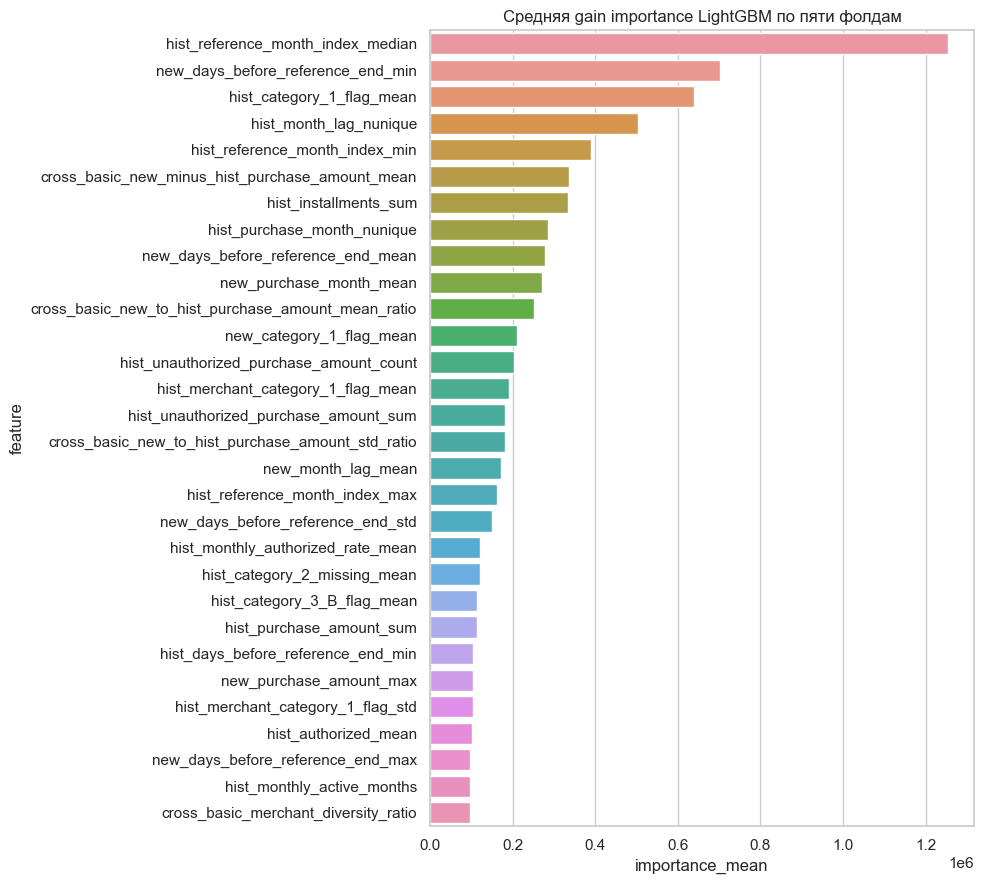

In [62]:
lgb_importance = tuned_lgb["importance"]

if lgb_importance is not None:
    display(lgb_importance.head(30))

    plt.figure(figsize=(10, 9))
    sns.barplot(
        data=lgb_importance.head(30),
        y="feature",
        x="importance_mean",
    )
    plt.title("Средняя gain importance LightGBM по пяти фолдам")
    plt.tight_layout()
    plt.show()


### 8.2. XGBoost: baseline → Optuna → bagging по seed

Сначала фиксирую понятную baseline-конфигурацию: стандартная регуляризация,
полная выборка строк и признаков, глубина 6. Затем Optuna отдельно подбирает
сложность деревьев, подвыборку и регуляризацию.


In [63]:
from xgboost import XGBRegressor

xgb_baseline_params = {
    "n_estimators": 5_000,
    "learning_rate": 0.03,
    "max_depth": 6,
    "min_child_weight": 1.0,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 200,
}

xgb_baseline = run_regression_cv(
    name="xgboost_baseline",
    model_factory=lambda fold_number: XGBRegressor(
        **xgb_baseline_params,
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "verbose": False,
    },
)

print("XGBoost baseline OOF RMSE:", xgb_baseline["OOF_RMSE"])


xgboost_baseline | fold 1/5 | RMSE=3.66026
xgboost_baseline | fold 2/5 | RMSE=3.66933
xgboost_baseline | fold 3/5 | RMSE=3.62901
xgboost_baseline | fold 4/5 | RMSE=3.64599
xgboost_baseline | fold 5/5 | RMSE=3.66534
XGBoost baseline OOF RMSE: 3.654017448425293


In [64]:
def xgboost_objective(trial):
    params = {
        "n_estimators": 5_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.06,
            log=True,
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            9,
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight",
            1.0,
            150.0,
            log=True,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0,
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.45,
            1.0,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            20.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            40.0,
            log=True,
        ),
        "gamma": trial.suggest_float(
            "gamma",
            0.0,
            5.0,
        ),
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "random_state": SEED,
        "n_jobs": -1,
        "early_stopping_rounds": 200,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        model = XGBRegressor(**params)
        model.fit(
            X_main.iloc[train_index],
            y.iloc[train_index],
            eval_set=[
                (
                    X_main.iloc[valid_index],
                    y.iloc[valid_index],
                )
            ],
            verbose=False,
        )
        prediction = model.predict(X_main.iloc[valid_index])
        scores.append(
            root_mean_squared_error(
                y.iloc[valid_index],
                prediction,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))


In [65]:
xgb_best_search_params, xgb_history, xgb_tuning_meta = run_optuna_search(
    study_name="xgboost",
    objective=xgboost_objective,
    n_trials=XGB_OPTUNA_TRIALS,
    direction="minimize",
)

xgb_best_params = {
    "n_estimators": 5_000,
    **xgb_best_search_params,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "n_jobs": -1,
    "early_stopping_rounds": 200,
}

display(pd.Series(xgb_best_params, name="value").to_frame())
display(pd.Series(xgb_tuning_meta, name="value").to_frame())
if not xgb_history.empty and "value" in xgb_history.columns:
    display(
        xgb_history.sort_values("value").head(10)
    )

tuned_xgb = run_regression_cv(
    name="xgboost_tuned",
    model_factory=lambda fold_number: XGBRegressor(
        **xgb_best_params,
        random_state=SEED,
    ),
    X=X_main,
    X_test=X_test_main,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "verbose": False,
    },
)

print("Tuned XGBoost OOF RMSE:", tuned_xgb["OOF_RMSE"])


c:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


,value
n_estimators,5000
learning_rate,0.014763
max_depth,6
min_child_weight,3.216629
subsample,0.693049
colsample_bytree,0.610604
reg_alpha,14.67555
reg_lambda,32.085957
gamma,1.762738
objective,reg:squarederror


,value
study_name,xgboost
direction,minimize
n_trials,60
best_value,3.645297
runtime_seconds,12160.855815
main_feature_set,+age-normalized
feature_count,336


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
41,41,3.645297,2026-08-05 00:01:36.043596,2026-08-05 00:04:50.524611,0 days 00:03:14.481015,0.610604,1.762738,0.014763,6,3.216629,14.675550,32.085957,0.693049,COMPLETE
44,44,3.646153,2026-08-05 00:12:09.395786,2026-08-05 00:15:31.946836,0 days 00:03:22.551050,0.519175,2.217602,0.013249,6,4.191867,5.315685,19.616000,0.699630,COMPLETE
46,46,3.646357,2026-08-05 00:18:58.990984,2026-08-05 00:21:44.986745,0 days 00:02:45.995761,0.530953,2.560938,0.019114,6,4.956770,15.447967,33.457090,0.678595,COMPLETE
43,43,3.646549,2026-08-05 00:08:21.054484,2026-08-05 00:12:09.395786,0 days 00:03:48.341302,0.635188,2.426712,0.014420,6,3.954725,6.011302,30.051991,0.742951,COMPLETE
47,47,3.646907,2026-08-05 00:21:44.986745,2026-08-05 00:24:39.470642,0 days 00:02:54.483897,0.526802,3.295650,0.017396,6,2.047451,4.824543,15.858703,0.702261,COMPLETE
45,45,3.646975,2026-08-05 00:15:31.946836,2026-08-05 00:18:58.990984,0 days 00:03:27.044148,0.487511,2.559498,0.015170,6,6.727728,14.594405,11.657739,0.744791,COMPLETE
31,31,3.647025,2026-08-04 23:25:50.436758,2026-08-04 23:29:27.090419,0 days 00:03:36.653661,0.491942,0.441987,0.015293,6,8.513368,9.831459,28.188750,0.996784,COMPLETE
53,53,3.647223,2026-08-05 00:42:35.385317,2026-08-05 00:46:35.668796,0 days 00:04:00.283479,0.608660,2.238109,0.011898,6,2.976975,17.333492,6.845592,0.732836,COMPLETE
58,58,3.647271,2026-08-05 00:57:03.244743,2026-08-05 00:59:35.719040,0 days 00:02:32.474297,0.486291,2.882952,0.021192,7,1.799995,11.203249,33.889813,0.729836,COMPLETE
48,48,3.647363,2026-08-05 00:24:39.470642,2026-08-05 00:28:20.164151,0 days 00:03:40.693509,0.574288,2.833014,0.013720,6,8.675079,0.119937,14.191870,0.601632,COMPLETE


xgboost_tuned | fold 1/5 | RMSE=3.64759
xgboost_tuned | fold 2/5 | RMSE=3.65296
xgboost_tuned | fold 3/5 | RMSE=3.61153
xgboost_tuned | fold 4/5 | RMSE=3.62877
xgboost_tuned | fold 5/5 | RMSE=3.66359
Tuned XGBoost OOF RMSE: 3.640937089920044


После настройки параметры фиксируются. Для bagging используются три заранее выбранных seed.
Они не отбираются по качеству: усредняются все три запуска.


In [66]:
XGB_BAGGING_SEEDS = [42, 17, 2026]

# tuned_xgb уже соответствует seed=42, поэтому повторно его не обучаю.
xgb_seed_results = [tuned_xgb]
xgb_seed_labels = [42]

for seed in XGB_BAGGING_SEEDS[1:]:
    result = run_regression_cv(
        name=f"xgboost_tuned_seed_{seed}",
        model_factory=lambda fold_number, seed=seed: XGBRegressor(
            **xgb_best_params,
            random_state=seed,
        ),
        X=X_main,
        X_test=X_test_main,
        fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
            "eval_set": [(X_valid, y_valid)],
            "verbose": False,
        },
    )
    xgb_seed_results.append(result)
    xgb_seed_labels.append(seed)

xgb_bag_oof = np.mean(
    [
        result["oof"]
        for result in xgb_seed_results
    ],
    axis=0,
).astype("float32")
xgb_bag_test = np.mean(
    [
        result["test"]
        for result in xgb_seed_results
    ],
    axis=0,
).astype("float32")
xgb_bag_fold_scores = (
    fold_scores_from_prediction(
        xgb_bag_oof
    )
)
xgb_bag_score = root_mean_squared_error(
    y,
    xgb_bag_oof,
)

seed_table = pd.DataFrame(
    {
        "seed": xgb_seed_labels + ["mean"],
        "OOF_RMSE": [
            result["OOF_RMSE"]
            for result in xgb_seed_results
        ] + [xgb_bag_score],
    }
)
display(seed_table)


xgboost_tuned_seed_17 | fold 1/5 | RMSE=3.64660
xgboost_tuned_seed_17 | fold 2/5 | RMSE=3.65389
xgboost_tuned_seed_17 | fold 3/5 | RMSE=3.60936
xgboost_tuned_seed_17 | fold 4/5 | RMSE=3.62947
xgboost_tuned_seed_17 | fold 5/5 | RMSE=3.66254
xgboost_tuned_seed_2026 | fold 1/5 | RMSE=3.64668
xgboost_tuned_seed_2026 | fold 2/5 | RMSE=3.65416
xgboost_tuned_seed_2026 | fold 3/5 | RMSE=3.61386
xgboost_tuned_seed_2026 | fold 4/5 | RMSE=3.62988
xgboost_tuned_seed_2026 | fold 5/5 | RMSE=3.66428


,seed,OOF_RMSE
0,42,3.640937
1,17,3.640421
2,2026,3.641819
3,mean,3.639754


### 8.3. CatBoost: baseline → Optuna

CatBoost получает исходные категориальные признаки как строки.
Baseline использует близкие к стандартным параметры, а Optuna подбирает глубину,
learning rate, L2-регуляризацию, случайность разбиений и Bayesian bagging.


In [67]:
from catboost import CatBoostRegressor

cat_feature_columns = [
    column
    for column in TREE_CATEGORICAL_COLUMNS
    if column in main_columns
]

X_cat_main = (
    full_train_features[main_columns]
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)
X_cat_test = (
    full_test_features[main_columns]
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)

cat_all_missing = [
    column
    for column in X_cat_main.columns
    if X_cat_main[column].isna().all()
]
X_cat_main = X_cat_main.drop(
    columns=cat_all_missing
)
X_cat_test = X_cat_test.drop(
    columns=cat_all_missing
)

cat_feature_columns = [
    column
    for column in cat_feature_columns
    if column in X_cat_main.columns
]
cat_numeric_columns = [
    column
    for column in X_cat_main.columns
    if column not in cat_feature_columns
]

for frame in [X_cat_main, X_cat_test]:
    for column in cat_feature_columns:
        frame[column] = (
            frame[column]
            .astype("Int64")
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )
    frame[cat_numeric_columns] = (
        frame[cat_numeric_columns]
        .astype("float32")
    )

assert list(X_cat_main.columns) == list(
    X_cat_test.columns
)

cat_baseline_params = {
    "iterations": 5_000,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "random_strength": 1.0,
    "bootstrap_type": "Bayesian",
    "bagging_temperature": 1.0,
    "loss_function": "RMSE",
    "random_seed": SEED,
    "verbose": False,
    "allow_writing_files": False,
}


In [68]:
cat_baseline = run_regression_cv(
    name="catboost_baseline",
    model_factory=lambda fold_number: CatBoostRegressor(
        **cat_baseline_params,
    ),
    X=X_cat_main,
    X_test=X_cat_test,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "cat_features": cat_feature_columns,
        "eval_set": (X_valid, y_valid),
        "early_stopping_rounds": 250,
        "verbose": False,
    },
)

print("CatBoost baseline OOF RMSE:", cat_baseline["OOF_RMSE"])


catboost_baseline | fold 1/5 | RMSE=3.65834
catboost_baseline | fold 2/5 | RMSE=3.66510
catboost_baseline | fold 3/5 | RMSE=3.62249
catboost_baseline | fold 4/5 | RMSE=3.63901
catboost_baseline | fold 5/5 | RMSE=3.67163
CatBoost baseline OOF RMSE: 3.6513571739196777


In [69]:
def catboost_objective(trial):
    params = {
        "iterations": 5_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True,
        ),
        "depth": trial.suggest_int(
            "depth",
            5,
            10,
        ),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            40.0,
            log=True,
        ),
        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            5.0,
        ),
        "bootstrap_type": "Bayesian",
        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            5.0,
        ),
        "loss_function": "RMSE",
        "random_seed": SEED,
        "verbose": False,
        "allow_writing_files": False,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        model = CatBoostRegressor(**params)
        model.fit(
            X_cat_main.iloc[train_index],
            y.iloc[train_index],
            cat_features=cat_feature_columns,
            eval_set=(
                X_cat_main.iloc[valid_index],
                y.iloc[valid_index],
            ),
            early_stopping_rounds=250,
            verbose=False,
        )
        prediction = model.predict(
            X_cat_main.iloc[valid_index]
        )
        scores.append(
            root_mean_squared_error(
                y.iloc[valid_index],
                prediction,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))


In [ ]:
cat_best_search_params, cat_history, cat_tuning_meta = run_optuna_search(
    study_name="catboost",
    objective=catboost_objective,
    n_trials=CAT_OPTUNA_TRIALS,
    direction="minimize",
)

cat_best_params = {
    "iterations": 5_000,
    **cat_best_search_params,
    "bootstrap_type": "Bayesian",
    "loss_function": "RMSE",
    "verbose": False,
    "allow_writing_files": False,
}

display(pd.Series(cat_best_params, name="value").to_frame())
display(pd.Series(cat_tuning_meta, name="value").to_frame())
if not cat_history.empty and "value" in cat_history.columns:
    display(
        cat_history.sort_values("value").head(10)
    )

tuned_cat = run_regression_cv(
    name="catboost_tuned",
    model_factory=lambda fold_number: CatBoostRegressor(
        **cat_best_params,
        random_seed=SEED,
    ),
    X=X_cat_main,
    X_test=X_cat_test,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "cat_features": cat_feature_columns,
        "eval_set": (X_valid, y_valid),
        "early_stopping_rounds": 250,
        "verbose": False,
    },
)

print("Tuned CatBoost OOF RMSE:", tuned_cat["OOF_RMSE"])


Сравниваю baseline и настроенные варианты каждой модели.


In [ ]:
tuning_comparison = pd.DataFrame(
    {
        "model": [
            "LightGBM baseline on selected features",
            "LightGBM tuned",
            "XGBoost baseline",
            "XGBoost tuned",
            "XGBoost tuned seed bagging",
            "CatBoost baseline",
            "CatBoost tuned",
        ],
        "OOF_RMSE": [
            lgb_baseline_main["OOF_RMSE"],
            tuned_lgb["OOF_RMSE"],
            xgb_baseline["OOF_RMSE"],
            tuned_xgb["OOF_RMSE"],
            xgb_bag_score,
            cat_baseline["OOF_RMSE"],
            tuned_cat["OOF_RMSE"],
        ],
    }
)
display(tuning_comparison)


## 9. Дополнительные гипотезы

### 9.1. Fold-safe target encoding

Проверяю только небольшое число интерпретируемых групп:

- комбинация `feature_1–3`;
- месяц первой активности;
- совместная комбинация.

Сглаживание не фиксируется заранее. На отдельной трёхфолдной схеме
сравниваются несколько значений и несколько наборов групп.


In [ ]:
def make_target_encoding_groups(frame: pd.DataFrame) -> pd.DataFrame:
    active = pd.to_datetime(
        frame["first_active_month"],
        format="%Y-%m",
        errors="coerce",
    )
    f1 = frame["feature_1"].astype("Int64").astype(str)
    f2 = frame["feature_2"].astype("Int64").astype(str)
    f3 = frame["feature_3"].astype("Int64").astype(str)
    active_period = (
        active.dt.year.astype("Int64").astype(str)
        + "_"
        + active.dt.month.astype("Int64").astype(str)
    )

    return pd.DataFrame(
        {
            "f123": f1 + "_" + f2 + "_" + f3,
            "active": active_period,
            "f123_active": (
                f1 + "_" + f2 + "_" + f3 + "_" + active_period
            ),
        }
    )

te_groups_train = make_target_encoding_groups(train)
te_groups_test = make_target_encoding_groups(test)

te_group_audit = []
for column in te_groups_train:
    counts = te_groups_train[column].value_counts()
    te_group_audit.append(
        {
            "group": column,
            "unique_train": counts.size,
            "median_group_size": counts.median(),
            "groups_size_1": int((counts == 1).sum()),
            "groups_size_lt_10": int((counts < 10).sum()),
            "unknown_test_rate": float(
                (~te_groups_test[column].isin(counts.index)).mean()
            ),
        }
    )
display(pd.DataFrame(te_group_audit))


In [ ]:
def fit_smooth_target_encoding(
    train_key,
    train_target,
    apply_key,
    smoothing,
):
    global_mean = float(np.mean(train_target))
    statistics = (
        pd.DataFrame(
            {
                "key": np.asarray(train_key),
                "target": np.asarray(train_target),
            }
        )
        .groupby("key")["target"]
        .agg(["sum", "count"])
    )

    encoding = (
        statistics["sum"] + smoothing * global_mean
    ) / (
        statistics["count"] + smoothing
    )

    return (
        pd.Series(np.asarray(apply_key))
        .map(encoding)
        .fillna(global_mean)
        .to_numpy("float32")
    )


Для обучающей части внешнего фолда target encoding тоже строится out-of-fold
по четырём внутренним фолдам. Так каждая строка получает среднее,
рассчитанное без её собственного target.

In [ ]:
def build_fold_safe_te_matrices(
    outer_train_index,
    outer_valid_index,
    group_names,
    smoothing,
    X_base,
    X_test_base,
    inner_seed,
):
    X_outer_train = X_base.iloc[outer_train_index].copy()
    X_outer_valid = X_base.iloc[outer_valid_index].copy()
    X_outer_test = X_test_base.copy()

    groups_outer_train = (
        te_groups_train
        .iloc[outer_train_index]
        .reset_index(drop=True)
    )
    target_outer_train = (
        y.iloc[outer_train_index]
        .reset_index(drop=True)
    )

    inner_splitter = KFold(
        n_splits=4,
        shuffle=True,
        random_state=inner_seed,
    )

    for group_name in group_names:
        encoded_outer_train = np.zeros(
            len(outer_train_index),
            dtype="float32",
        )

        for inner_train, inner_valid in inner_splitter.split(
            groups_outer_train
        ):
            encoded_outer_train[inner_valid] = (
                fit_smooth_target_encoding(
                    groups_outer_train.iloc[inner_train][group_name],
                    target_outer_train.iloc[inner_train],
                    groups_outer_train.iloc[inner_valid][group_name],
                    smoothing=smoothing,
                )
            )

        X_outer_train[f"te_{group_name}"] = encoded_outer_train
        X_outer_valid[f"te_{group_name}"] = (
            fit_smooth_target_encoding(
                groups_outer_train[group_name],
                target_outer_train,
                te_groups_train.iloc[outer_valid_index][group_name],
                smoothing=smoothing,
            )
        )
        X_outer_test[f"te_{group_name}"] = (
            fit_smooth_target_encoding(
                groups_outer_train[group_name],
                target_outer_train,
                te_groups_test[group_name],
                smoothing=smoothing,
            )
        )

    return X_outer_train, X_outer_valid, X_outer_test


Сравниваю пять значений сглаживания и три набора групп.
Каждый вариант оценивается на одной и той же трёхфолдной схеме.

In [ ]:
TE_SMOOTHING_GRID = [
    10.0,
    30.0,
    80.0,
    150.0,
    300.0,
]
TE_GROUP_SETS = {
    "f123": ["f123"],
    "f123+active": ["f123", "active"],
    "all_groups": [
        "f123",
        "active",
        "f123_active",
    ],
}

te_search_table = pd.DataFrame(
    columns=[
        "group_set",
        "smoothing",
        "mean_RMSE",
        "std_RMSE",
    ]
)

In [ ]:
for group_set_name, group_names in TE_GROUP_SETS.items():
    for smoothing in TE_SMOOTHING_GRID:
        candidate_scores = []

        for fold_number, (
            train_index,
            valid_index,
        ) in enumerate(tuning_folds, start=1):
            (
                X_te_train,
                X_te_valid,
                _,
            ) = build_fold_safe_te_matrices(
                train_index,
                valid_index,
                group_names=group_names,
                smoothing=smoothing,
                X_base=X_main,
                X_test_base=X_test_main,
                inner_seed=SEED + 1_000 + fold_number,
            )

            model = XGBRegressor(
                **xgb_best_params,
                random_state=SEED,
            )
            model.fit(
                X_te_train,
                y.iloc[train_index],
                eval_set=[
                    (
                        X_te_valid,
                        y.iloc[valid_index],
                    )
                ],
                verbose=False,
            )
            prediction = model.predict(X_te_valid)
            candidate_scores.append(
                root_mean_squared_error(
                    y.iloc[valid_index],
                    prediction,
                )
            )

        candidate_row = pd.DataFrame(
            [
                {
                    "group_set": group_set_name,
                    "smoothing": smoothing,
                    "mean_RMSE": float(np.mean(candidate_scores)),
                    "std_RMSE": float(
                        np.std(candidate_scores, ddof=1)
                    ),
                }
            ]
        )
        te_search_table = pd.concat(
            [te_search_table, candidate_row],
            ignore_index=True,
        )

display(
    te_search_table.sort_values("mean_RMSE").head(15)
)


In [ ]:
best_te_row = (
    te_search_table
    .sort_values(["mean_RMSE", "std_RMSE"])
    .iloc[0]
)
BEST_TE_GROUP_SET = best_te_row["group_set"]
BEST_TE_GROUPS = TE_GROUP_SETS[BEST_TE_GROUP_SET]
BEST_TE_SMOOTHING = float(best_te_row["smoothing"])

print("Выбранный набор групп:", BEST_TE_GROUP_SET)
print("Выбранное сглаживание:", BEST_TE_SMOOTHING)


После выбора параметров получаю итоговые пятифолдные OOF- и test-прогнозы.


In [ ]:
te_oof = np.zeros(len(y), dtype="float32")
te_test = np.zeros(len(X_test_main), dtype="float32")
te_fold_scores = []
te_start_time = time.perf_counter()

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    (
        X_te_train,
        X_te_valid,
        X_te_test,
    ) = build_fold_safe_te_matrices(
        train_index,
        valid_index,
        group_names=BEST_TE_GROUPS,
        smoothing=BEST_TE_SMOOTHING,
        X_base=X_main,
        X_test_base=X_test_main,
        inner_seed=SEED + 2_000 + fold_number,
    )

    model = XGBRegressor(
        **xgb_best_params,
        random_state=SEED,
    )
    model.fit(
        X_te_train,
        y.iloc[train_index],
        eval_set=[
            (
                X_te_valid,
                y.iloc[valid_index],
            )
        ],
        verbose=False,
    )

    te_oof[valid_index] = model.predict(X_te_valid)
    te_test += model.predict(X_te_test) / len(primary_folds)

    score = root_mean_squared_error(
        y.iloc[valid_index],
        te_oof[valid_index],
    )
    te_fold_scores.append(float(score))
    print(
        f"XGBoost + TE | fold {fold_number}/{len(primary_folds)} "
        f"| RMSE={score:.5f}"
    )

te_runtime = time.perf_counter() - te_start_time
te_score = root_mean_squared_error(y, te_oof)

display(
    pd.DataFrame(
        {
            "model": ["Tuned XGBoost", "Tuned XGBoost + TE"],
            "OOF_RMSE": [
                tuned_xgb["OOF_RMSE"],
                te_score,
            ],
        }
    )
)


### 9.2. Отдельная модель экстремального сегмента

Классификатор не заменяет регрессию. Он нужен только для проверки,
может ли вероятность экстремального target улучшить итоговый RMSE.

Параметры LightGBMClassifier подбираются по PR-AUC, поскольку положительный класс редкий.
ROC-AUC выводится только как дополнительная характеристика.


Сначала оцениваю консервативный baseline-классификатор.
Это показывает, дал ли последующий Optuna-поиск реальное улучшение PR-AUC.


In [ ]:
from lightgbm import LGBMClassifier

extreme_target = (
    extreme_indicator.to_numpy()
)

outlier_baseline_params = {
    "n_estimators": 3_000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    "subsample_freq": 1,
}

outlier_baseline_oof = np.zeros(
    len(y),
    dtype="float32",
)

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    positives = extreme_target[
        train_index
    ].sum()
    negatives = (
        len(train_index) - positives
    )

    baseline_classifier = (
        LGBMClassifier(
            **outlier_baseline_params,
            scale_pos_weight=(
                negatives
                / max(positives, 1)
            ),
        )
    )
    baseline_classifier.fit(
        X_main.iloc[train_index],
        extreme_target[train_index],
        eval_set=[
            (
                X_main.iloc[valid_index],
                extreme_target[valid_index],
            )
        ],
        callbacks=[
            lgb.early_stopping(
                180,
                verbose=False,
            )
        ],
    )

    outlier_baseline_oof[
        valid_index
    ] = baseline_classifier.predict_proba(
        X_main.iloc[valid_index]
    )[:, 1]

outlier_baseline_pr_auc = (
    average_precision_score(
        extreme_target,
        outlier_baseline_oof,
    )
)
outlier_baseline_roc_auc = (
    roc_auc_score(
        extreme_target,
        outlier_baseline_oof,
    )
)

print(
    "Baseline PR-AUC:",
    outlier_baseline_pr_auc,
)
print(
    "Baseline ROC-AUC:",
    outlier_baseline_roc_auc,
)


Теперь подбираю сложность деревьев, подвыборку и регуляризацию
на отдельной трёхфолдной схеме.


In [ ]:
def outlier_classifier_objective(trial):
    max_depth = trial.suggest_int("max_depth", 3, 9)
    max_leaves = min(64, 2 ** max_depth)

    params = {
        "n_estimators": 4_000,
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.06,
            log=True,
        ),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int(
            "num_leaves",
            8,
            max_leaves,
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            20,
            200,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.65,
            1.0,
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            20.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-4,
            30.0,
            log=True,
        ),
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
    }

    scores = []
    for fold_number, (train_index, valid_index) in enumerate(tuning_folds):
        positives = extreme_target[train_index].sum()
        negatives = len(train_index) - positives

        model = LGBMClassifier(
            **params,
            scale_pos_weight=negatives / max(positives, 1),
        )
        model.fit(
            X_main.iloc[train_index],
            extreme_target[train_index],
            eval_set=[
                (
                    X_main.iloc[valid_index],
                    extreme_target[valid_index],
                )
            ],
            callbacks=[
                lgb.early_stopping(180, verbose=False)
            ],
        )

        probability = model.predict_proba(
            X_main.iloc[valid_index]
        )[:, 1]
        scores.append(
            average_precision_score(
                extreme_target[valid_index],
                probability,
            )
        )

        trial.report(float(np.mean(scores)), fold_number)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))


In [ ]:
outlier_best_search_params, outlier_history, outlier_tuning_meta = (
    run_optuna_search(
        study_name="outlier_classifier",
        objective=outlier_classifier_objective,
        n_trials=OUTLIER_OPTUNA_TRIALS,
        direction="maximize",
    )
)

outlier_best_params = {
    "n_estimators": 4_000,
    **outlier_best_search_params,
    "subsample_freq": 1,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
}

display(pd.Series(outlier_best_params, name="value").to_frame())
display(pd.Series(outlier_tuning_meta, name="value").to_frame())
if (
    not outlier_history.empty
    and "value" in outlier_history.columns
):
    display(
        outlier_history.sort_values(
            "value",
            ascending=False,
        ).head(10)
    )


In [ ]:
outlier_oof = np.zeros(len(y), dtype="float32")
outlier_test = np.zeros(len(X_test_main), dtype="float32")
outlier_fold_pr_auc = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    positives = extreme_target[train_index].sum()
    negatives = len(train_index) - positives

    model = LGBMClassifier(
        **outlier_best_params,
        scale_pos_weight=negatives / max(positives, 1),
    )
    model.fit(
        X_main.iloc[train_index],
        extreme_target[train_index],
        eval_set=[
            (
                X_main.iloc[valid_index],
                extreme_target[valid_index],
            )
        ],
        callbacks=[
            lgb.early_stopping(200, verbose=False)
        ],
    )

    outlier_oof[valid_index] = model.predict_proba(
        X_main.iloc[valid_index]
    )[:, 1]
    outlier_test += (
        model.predict_proba(X_test_main)[:, 1]
        / len(primary_folds)
    )

    outlier_fold_pr_auc.append(
        average_precision_score(
            extreme_target[valid_index],
            outlier_oof[valid_index],
        )
    )

print(
    "OOF ROC-AUC:",
    roc_auc_score(extreme_target, outlier_oof),
)
print(
    "OOF PR-AUC:",
    average_precision_score(extreme_target, outlier_oof),
)
print(
    "PR-AUC по фолдам:",
    np.round(outlier_fold_pr_auc, 4),
)


outlier_tuned_pr_auc = average_precision_score(
    extreme_target,
    outlier_oof,
)
outlier_tuned_roc_auc = roc_auc_score(
    extreme_target,
    outlier_oof,
)

display(
    pd.DataFrame(
        {
            "classifier": [
                "baseline",
                "tuned",
            ],
            "OOF_PR_AUC": [
                outlier_baseline_pr_auc,
                outlier_tuned_pr_auc,
            ],
            "OOF_ROC_AUC": [
                outlier_baseline_roc_auc,
                outlier_tuned_roc_auc,
            ],
        }
    )
)


In [ ]:
calibration_frame = pd.DataFrame(
    {
        "probability": outlier_oof,
        "extreme": extreme_target,
    }
)
calibration_frame["bin"] = pd.qcut(
    calibration_frame["probability"],
    10,
    duplicates="drop",
)

calibration_table = (
    calibration_frame
    .groupby("bin", observed=False)
    .agg(
        mean_probability=("probability", "mean"),
        observed_rate=("extreme", "mean"),
        cards=("extreme", "size"),
    )
)
display(calibration_table)

threshold_diagnostics = []
for threshold in np.quantile(
    outlier_oof,
    [0.80, 0.90, 0.95, 0.97, 0.99],
):
    matrix = confusion_matrix(
        extreme_target,
        outlier_oof >= threshold,
    )
    tn, fp, fn, tp = matrix.ravel()
    threshold_diagnostics.append(
        {
            "threshold": threshold,
            "cards_selected": int((outlier_oof >= threshold).sum()),
            "true_positive": int(tp),
            "false_positive": int(fp),
            "false_negative": int(fn),
        }
    )

display(pd.DataFrame(threshold_diagnostics))


## 10. Сравнение одиночных моделей

Собираю результаты основных моделей в едином формате.
В таблице есть не только общий OOF RMSE, но и разброс фолдов и время обучения.


In [ ]:
def custom_result_summary(
    name,
    oof,
    test_prediction,
    fold_scores,
    runtime_seconds=np.nan,
):
    return {
        "name": name,
        "oof": np.asarray(oof),
        "test": np.asarray(test_prediction),
        "fold_scores": list(fold_scores),
        "OOF_RMSE": float(root_mean_squared_error(y, oof)),
        "fold_mean_RMSE": float(np.mean(fold_scores)),
        "fold_std_RMSE": float(np.std(fold_scores, ddof=1)),
        "fold_min_RMSE": float(np.min(fold_scores)),
        "fold_max_RMSE": float(np.max(fold_scores)),
        "runtime_seconds": float(runtime_seconds),
    }

xgb_bag_result = custom_result_summary(
    "xgboost_seed_bagging",
    xgb_bag_oof,
    xgb_bag_test,
    xgb_bag_fold_scores,
    runtime_seconds=sum(
        result["runtime_seconds"]
        for result in xgb_seed_results
    ),
)
te_result = custom_result_summary(
    "xgboost_target_encoding",
    te_oof,
    te_test,
    te_fold_scores,
    runtime_seconds=te_runtime,
)

all_single_model_results = {
    "lightgbm_tuned": tuned_lgb,
    "xgboost_tuned": tuned_xgb,
    "xgboost_seed_bagging": xgb_bag_result,
    "catboost_tuned": tuned_cat,
    "xgboost_target_encoding": te_result,
}

single_model_table = pd.DataFrame(
    [
        {
            "model": name,
            "OOF_RMSE": result["OOF_RMSE"],
            "fold_mean_RMSE": result["fold_mean_RMSE"],
            "fold_std_RMSE": result["fold_std_RMSE"],
            "fold_min_RMSE": result["fold_min_RMSE"],
            "fold_max_RMSE": result["fold_max_RMSE"],
            "cv_runtime_minutes": result["runtime_seconds"] / 60,
        }
        for name, result in all_single_model_results.items()
    ]
).sort_values("OOF_RMSE")

display(single_model_table)

if xgb_bag_score < tuned_xgb["OOF_RMSE"]:
    XGB_ENSEMBLE_NAME = "xgboost_seed_bagging"
    xgb_ensemble_result = xgb_bag_result
else:
    XGB_ENSEMBLE_NAME = "xgboost_tuned"
    xgb_ensemble_result = tuned_xgb

# В blend не включаю одновременно tuned XGBoost и его bagging-версию:
# это почти дублирующие источники прогноза.
single_model_results = {
    "lightgbm_tuned": tuned_lgb,
    XGB_ENSEMBLE_NAME: xgb_ensemble_result,
    "catboost_tuned": tuned_cat,
    "xgboost_target_encoding": te_result,
}

print(
    "XGBoost-кандидат для ансамбля:",
    XGB_ENSEMBLE_NAME,
)


Корреляция остатков показывает разнообразие моделей.
Для ансамбля полезна не только самая точная модель, но и модель,
которая ошибается иначе.


In [ ]:
residual_correlation = pd.DataFrame(
    {
        name: y.to_numpy() - result["oof"]
        for name, result in single_model_results.items()
    }
).corr()

display(residual_correlation.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(
    residual_correlation,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    vmin=0.8,
    vmax=1.0,
)
plt.title("Корреляция OOF-остатков")
plt.tight_layout()
plt.show()


## 11. Ансамбли

Использую стандартную практическую схему на OOF-прогнозах.
Каждая строка базовой OOF-матрицы получена моделью, не обученной на target этой строки.

Весовой blend и Ridge-метамодель дополнительно оцениваются по метафолдам.
Это снижает прямое переобучение метауровня, но не является полной nested CV
с повторным обучением всех базовых моделей внутри каждого метафолда.
Поэтому микроскопические улучшения интерпретируются осторожно.

### 11.1. Weighted blend


In [ ]:
from scipy.optimize import minimize

base_oof = {
    name: result["oof"]
    for name, result in single_model_results.items()
}
base_test = {
    name: result["test"]
    for name, result in single_model_results.items()
}

def fit_nonnegative_blend_weights(
    target,
    prediction_matrix,
):
    initial = np.full(
        prediction_matrix.shape[1],
        1 / prediction_matrix.shape[1],
    )

    optimization = minimize(
        lambda weights: root_mean_squared_error(
            target,
            prediction_matrix @ weights,
        ),
        initial,
        method="SLSQP",
        bounds=[
            (0.0, 1.0)
            for _ in range(prediction_matrix.shape[1])
        ],
        constraints={
            "type": "eq",
            "fun": lambda weights: weights.sum() - 1.0,
        },
        options={
            "maxiter": 500,
            "ftol": 1e-10,
        },
    )

    if not optimization.success:
        raise RuntimeError(optimization.message)

    return optimization.x


In [ ]:
model_names = list(base_oof)
oof_matrix = np.column_stack(
    [base_oof[name] for name in model_names]
)
test_matrix = np.column_stack(
    [base_test[name] for name in model_names]
)

blend_oof = np.zeros(len(y), dtype="float32")
blend_fold_weight_rows = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    weights = fit_nonnegative_blend_weights(
        y.iloc[train_index],
        oof_matrix[train_index],
    )
    blend_oof[valid_index] = (
        oof_matrix[valid_index] @ weights
    )

    blend_fold_weight_rows.append(
        {
            "fold": fold_number,
            **{
                name: float(weight)
                for name, weight in zip(model_names, weights)
            },
        }
    )

final_blend_weights_array = fit_nonnegative_blend_weights(
    y,
    oof_matrix,
)
blend_test = test_matrix @ final_blend_weights_array

blend_fold_scores = fold_scores_from_prediction(blend_oof)
blend_result = custom_result_summary(
    "weighted_blend",
    blend_oof,
    blend_test,
    blend_fold_scores,
)

display(pd.DataFrame(blend_fold_weight_rows))
display(
    pd.Series(
        final_blend_weights_array,
        index=model_names,
        name="final_weight",
    ).to_frame()
)
print("Weighted blend OOF RMSE:", blend_result["OOF_RMSE"])


### 11.2. Ridge stacking

Диапазон `alpha` покрывает слабую и сильную регуляризацию в логарифмическом масштабе.
Конкретное значение выбирается внутри каждого метафолда.

Коэффициенты ниже относятся к стандартизованным OOF-прогнозам, поэтому их масштаб нельзя напрямую трактовать как веса обычного среднего.


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

stack_oof = np.zeros(len(y), dtype="float32")
stack_fold_rows = []
stack_coefficient_rows = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    meta_model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 40)),
    )
    meta_model.fit(
        oof_matrix[train_index],
        y.iloc[train_index],
    )
    stack_oof[valid_index] = meta_model.predict(
        oof_matrix[valid_index]
    )

    ridge_model = meta_model.named_steps["ridgecv"]
    stack_fold_rows.append(
        {
            "fold": fold_number,
            "alpha": float(ridge_model.alpha_),
            "valid_RMSE": root_mean_squared_error(
                y.iloc[valid_index],
                stack_oof[valid_index],
            ),
        }
    )
    stack_coefficient_rows.append(
        {
            "fold": fold_number,
            **{
                name: float(coefficient)
                for name, coefficient in zip(
                    model_names,
                    ridge_model.coef_,
                )
            },
        }
    )

final_stack_model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-4, 4, 40)),
)
final_stack_model.fit(oof_matrix, y)
stack_test = final_stack_model.predict(test_matrix)

stack_fold_scores = fold_scores_from_prediction(stack_oof)
stack_result = custom_result_summary(
    "ridge_stacking",
    stack_oof,
    stack_test,
    stack_fold_scores,
)

display(pd.DataFrame(stack_fold_rows))
display(pd.DataFrame(stack_coefficient_rows))
print("Ridge stacking OOF RMSE:", stack_result["OOF_RMSE"])


### 11.3. Проверка корректировки экстремального сегмента

Порог вероятности и значение замены не задаются вручную.

- пороги берутся из квантилей OOF-вероятности классификатора;
- кандидаты замены строятся по фактическому распределению экстремального target;
- параметры подбираются только на train-части метафолда и применяются к validation.

Корректировка останется отдельным экспериментом, если не улучшит общий RMSE устойчиво.


In [ ]:
threshold_grid = np.unique(
    np.quantile(
        outlier_oof,
        [0.75, 0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.99],
    )
)

extreme_values = y[extreme_indicator == 1]
replacement_grid = np.unique(
    np.concatenate(
        [
            np.quantile(
                extreme_values,
                [0.10, 0.25, 0.50, 0.75, 0.90],
            ),
            np.linspace(
                float(extreme_values.mean()),
                float(y.quantile(0.01)),
                6,
            ),
        ]
    )
)

print("Порогов вероятности:", len(threshold_grid))
print("Кандидатов замены:", len(replacement_grid))
display(
    pd.DataFrame(
        {
            "threshold_grid": pd.Series(threshold_grid),
            "replacement_grid": pd.Series(replacement_grid),
        }
    )
)


In [ ]:
corrected_oof = np.zeros(len(y), dtype="float32")
correction_rows = []

for fold_number, (
    train_index,
    valid_index,
) in enumerate(primary_folds, start=1):
    best_train_score = np.inf
    best_parameters = None

    for threshold in threshold_grid:
        for replacement in replacement_grid:
            train_candidate = blend_oof[train_index].copy()
            selected_train = (
                outlier_oof[train_index] >= threshold
            )
            train_candidate[selected_train] = replacement

            denominator = float(
                np.sum(outlier_oof[train_index] ** 2)
            )
            alpha = 0.0
            if denominator > 0:
                alpha = max(
                    0.0,
                    float(
                        np.sum(
                            outlier_oof[train_index]
                            * (
                                train_candidate
                                - y.iloc[train_index].to_numpy()
                            )
                        )
                        / denominator
                    ),
                )

            train_adjusted = (
                train_candidate
                - alpha * outlier_oof[train_index]
            )
            train_score = root_mean_squared_error(
                y.iloc[train_index],
                train_adjusted,
            )

            if train_score < best_train_score:
                best_train_score = train_score
                best_parameters = (
                    float(threshold),
                    float(replacement),
                    float(alpha),
                )

    threshold, replacement, alpha = best_parameters

    valid_prediction = blend_oof[valid_index].copy()
    selected_valid = (
        outlier_oof[valid_index] >= threshold
    )
    valid_prediction[selected_valid] = replacement
    valid_prediction = (
        valid_prediction
        - alpha * outlier_oof[valid_index]
    )
    corrected_oof[valid_index] = valid_prediction

    correction_rows.append(
        {
            "fold": fold_number,
            "threshold": threshold,
            "replacement": replacement,
            "alpha": alpha,
            "valid_cards_changed": int(selected_valid.sum()),
            "valid_RMSE": root_mean_squared_error(
                y.iloc[valid_index],
                valid_prediction,
            ),
        }
    )

correction_table = pd.DataFrame(correction_rows)
display(correction_table)


In [ ]:
# Для test параметры оцениваются на всей OOF-выборке.
best_full_score = np.inf
best_full_parameters = None

for threshold in threshold_grid:
    for replacement in replacement_grid:
        candidate = blend_oof.copy()
        selected = outlier_oof >= threshold
        candidate[selected] = replacement

        denominator = float(np.sum(outlier_oof ** 2))
        alpha = 0.0
        if denominator > 0:
            alpha = max(
                0.0,
                float(
                    np.sum(
                        outlier_oof
                        * (candidate - y.to_numpy())
                    )
                    / denominator
                ),
            )

        adjusted = candidate - alpha * outlier_oof
        score = root_mean_squared_error(y, adjusted)

        if score < best_full_score:
            best_full_score = score
            best_full_parameters = (
                float(threshold),
                float(replacement),
                float(alpha),
            )

full_threshold, full_replacement, full_alpha = best_full_parameters

corrected_test = blend_test.copy()
selected_test = outlier_test >= full_threshold
corrected_test[selected_test] = full_replacement
corrected_test = (
    corrected_test - full_alpha * outlier_test
)

corrected_fold_scores = fold_scores_from_prediction(corrected_oof)
corrected_result = custom_result_summary(
    "outlier_corrected_blend",
    corrected_oof,
    corrected_test,
    corrected_fold_scores,
)

print(
    "Outlier-corrected blend OOF RMSE:",
    corrected_result["OOF_RMSE"],
)
print(
    "Изменено test-карт:",
    int(selected_test.sum()),
)


In [ ]:
segment_comparison = pd.DataFrame(
    {
        "segment": [
            f"target < {EXTREME_THRESHOLD}",
            f"target >= {EXTREME_THRESHOLD}",
        ],
        "weighted_blend_RMSE": [
            root_mean_squared_error(
                y[extreme_indicator == 1],
                blend_oof[extreme_indicator == 1],
            ),
            root_mean_squared_error(
                y[extreme_indicator == 0],
                blend_oof[extreme_indicator == 0],
            ),
        ],
        "corrected_blend_RMSE": [
            root_mean_squared_error(
                y[extreme_indicator == 1],
                corrected_oof[extreme_indicator == 1],
            ),
            root_mean_squared_error(
                y[extreme_indicator == 0],
                corrected_oof[extreme_indicator == 0],
            ),
        ],
    }
)
display(segment_comparison)


## 12. Финальное сравнение

Сначала нахожу лучший OOF-результат среди всех кандидатов.
Затем сравниваю его с лучшей одиночной моделью с помощью парного бутстрэпа.
Сложный ансамбль выбирается только в том случае, если его преимущество
остаётся отрицательным по всей 95%-й бутстрэп-оценке разницы RMSE.

In [ ]:
candidate_results = {
    "lightgbm_tuned": tuned_lgb,
    "xgboost_tuned": tuned_xgb,
    "xgboost_seed_bagging": xgb_bag_result,
    "catboost_tuned": tuned_cat,
    "xgboost_target_encoding": te_result,
    "weighted_blend": blend_result,
    "ridge_stacking": stack_result,
    "outlier_corrected_blend": corrected_result,
}

complexity_rank = {
    "lightgbm_tuned": 1,
    "xgboost_tuned": 1,
    "catboost_tuned": 1,
    "xgboost_seed_bagging": 2,
    "xgboost_target_encoding": 2,
    "weighted_blend": 3,
    "ridge_stacking": 4,
    "outlier_corrected_blend": 5,
}

final_rows = []
for name, result in candidate_results.items():
    final_rows.append(
        {
            "model": name,
            "complexity_rank": complexity_rank[name],
            "OOF_RMSE": result["OOF_RMSE"],
            "fold_mean_RMSE": result["fold_mean_RMSE"],
            "fold_std_RMSE": result["fold_std_RMSE"],
            "fold_min_RMSE": result["fold_min_RMSE"],
            "fold_max_RMSE": result["fold_max_RMSE"],
            "cv_runtime_minutes": result["runtime_seconds"] / 60,
        }
    )

final_results = pd.DataFrame(final_rows).sort_values(
    ["OOF_RMSE", "complexity_rank"],
    ignore_index=True,
)
display(final_results)


In [ ]:
NUMERICAL_BEST_MODEL_NAME = final_results.iloc[0]["model"]
BEST_SINGLE_MODEL_NAME = single_model_table.iloc[0]["model"]

numerical_best_result = candidate_results[
    NUMERICAL_BEST_MODEL_NAME
]
best_single_result = candidate_results[
    BEST_SINGLE_MODEL_NAME
]

print("Численно лучший кандидат:", NUMERICAL_BEST_MODEL_NAME)
print("Лучшая одиночная модель:", BEST_SINGLE_MODEL_NAME)
print(
    "Разница OOF RMSE:",
    numerical_best_result["OOF_RMSE"]
    - best_single_result["OOF_RMSE"],
)

Бутстрэп выполняется по одним и тем же строкам, поэтому сравнение парное.
Отрицательная разница означает, что численно лучший кандидат лучше
лучшей одиночной модели.

In [ ]:
def bootstrap_rmse_difference(
    target,
    prediction_a,
    prediction_b,
    iterations,
    seed,
):
    rng = np.random.default_rng(seed)
    target_array = np.asarray(target)
    prediction_a = np.asarray(prediction_a)
    prediction_b = np.asarray(prediction_b)

    differences = np.empty(iterations, dtype=float)

    for iteration in range(iterations):
        sample_index = rng.integers(
            0,
            len(target_array),
            size=len(target_array),
        )
        rmse_a = root_mean_squared_error(
            target_array[sample_index],
            prediction_a[sample_index],
        )
        rmse_b = root_mean_squared_error(
            target_array[sample_index],
            prediction_b[sample_index],
        )
        differences[iteration] = rmse_a - rmse_b

    return differences


if NUMERICAL_BEST_MODEL_NAME == BEST_SINGLE_MODEL_NAME:
    bootstrap_difference = np.zeros(
        BOOTSTRAP_ITERATIONS,
        dtype=float,
    )
    SELECTED_MODEL_NAME = BEST_SINGLE_MODEL_NAME
else:
    bootstrap_difference = bootstrap_rmse_difference(
        y,
        numerical_best_result["oof"],
        best_single_result["oof"],
        iterations=BOOTSTRAP_ITERATIONS,
        seed=SEED,
    )

    upper_bound = np.quantile(
        bootstrap_difference,
        0.975,
    )
    SELECTED_MODEL_NAME = (
        NUMERICAL_BEST_MODEL_NAME
        if upper_bound < 0
        else BEST_SINGLE_MODEL_NAME
    )

selected_result = candidate_results[
    SELECTED_MODEL_NAME
]

bootstrap_summary = pd.Series(
    {
        "numerical_best": NUMERICAL_BEST_MODEL_NAME,
        "best_single": BEST_SINGLE_MODEL_NAME,
        "mean(best - single)": bootstrap_difference.mean(),
        "2.5%": np.quantile(bootstrap_difference, 0.025),
        "50%": np.quantile(bootstrap_difference, 0.50),
        "97.5%": np.quantile(bootstrap_difference, 0.975),
        "selected_model": SELECTED_MODEL_NAME,
    },
    name="value",
)
display(bootstrap_summary.to_frame())

### Как трактовать результат

Если ансамбль выигрывает у лучшей одиночной модели устойчиво по бутстрэпу,
использую ансамбль. Если интервал включает ноль, оставляю более простую
одиночную модель. Leaderboard в этом выборе не участвует.

## 13. Проверка устойчивости основных моделей

Дополнительно повторяю tuned LightGBM и tuned XGBoost на другом разбиении.

In [ ]:
alternative_splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=2026,
)
alternative_folds = list(
    alternative_splitter.split(
        np.zeros(len(y)),
        extreme_indicator,
    )
)


In [ ]:
alternative_lgb = run_regression_cv(
    name="lightgbm_tuned_alt_folds",
    model_factory=lambda fold_number: lgb.LGBMRegressor(
        **lgb_best_params
    ),
    X=X_main,
    X_test=X_test_main,
    folds=alternative_folds,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "callbacks": [
            lgb.early_stopping(200, verbose=False)
        ],
    },
)

alternative_xgb = run_regression_cv(
    name="xgboost_tuned_alt_folds",
    model_factory=lambda fold_number: XGBRegressor(
        **xgb_best_params,
        random_state=SEED,
    ),
    X=X_main,
    X_test=X_test_main,
    folds=alternative_folds,
    fit_kwargs_builder=lambda model, X_train, y_train, X_valid, y_valid: {
        "eval_set": [(X_valid, y_valid)],
        "verbose": False,
    },
)

stability_table = pd.DataFrame(
    [
        {
            "model": "LightGBM",
            "split_seed": 42,
            "OOF_RMSE": tuned_lgb["OOF_RMSE"],
            "fold_std_RMSE": tuned_lgb["fold_std_RMSE"],
        },
        {
            "model": "LightGBM",
            "split_seed": 2026,
            "OOF_RMSE": alternative_lgb["OOF_RMSE"],
            "fold_std_RMSE": alternative_lgb["fold_std_RMSE"],
        },
        {
            "model": "XGBoost",
            "split_seed": 42,
            "OOF_RMSE": tuned_xgb["OOF_RMSE"],
            "fold_std_RMSE": tuned_xgb["fold_std_RMSE"],
        },
        {
            "model": "XGBoost",
            "split_seed": 2026,
            "OOF_RMSE": alternative_xgb["OOF_RMSE"],
            "fold_std_RMSE": alternative_xgb["fold_std_RMSE"],
        },
    ]
)
display(stability_table)


## 14. Журнал исследовательских итераций

Журнал формируется из фактических результатов.
Решения не задаются заранее: текст зависит от измеренного улучшения.


Сначала фиксирую baseline и результаты абляции признаков.


In [ ]:
experiment_log = [
    {
        "stage": "baseline",
        "experiment": "DummyRegressor",
        "OOF_RMSE": dummy_score,
        "decision": "нижняя граница качества",
    },
    {
        "stage": "baseline",
        "experiment": "RidgeCV on raw card features",
        "OOF_RMSE": ridge_score,
        "decision": (
            "лучше постоянного прогноза"
            if ridge_score < dummy_score
            else "линейная модель не улучшила dummy"
        ),
    },
]

for row in ablation_table.itertuples():
    experiment_log.append(
        {
            "stage": "feature ablation",
            "experiment": row.feature_set,
            "OOF_RMSE": row.OOF_RMSE,
            "decision": (
                "выбран как основной набор"
                if row.feature_set == MAIN_FEATURE_SET
                else "сохранён только для сравнения"
            ),
        }
    )


Затем добавляю результаты подбора параметров.


In [ ]:
model_comparisons = [
    (
        "LightGBM tuning",
        lgb_baseline_main["OOF_RMSE"],
        tuned_lgb["OOF_RMSE"],
    ),
    (
        "XGBoost tuning",
        xgb_baseline["OOF_RMSE"],
        tuned_xgb["OOF_RMSE"],
    ),
    (
        "CatBoost tuning",
        cat_baseline["OOF_RMSE"],
        tuned_cat["OOF_RMSE"],
    ),
]

for name, baseline_score, tuned_score in model_comparisons:
    experiment_log.append(
        {
            "stage": "hyperparameter tuning",
            "experiment": name,
            "OOF_RMSE": tuned_score,
            "decision": (
                f"улучшение "
                f"{baseline_score - tuned_score:.5f}"
                if tuned_score < baseline_score
                else "подбор не дал улучшения"
            ),
        }
    )


Последними записываются дополнительные гипотезы, ансамбли и финальный выбор.


In [ ]:
experiment_log.extend(
    [
        {
            "stage": "additional hypothesis",
            "experiment": "XGBoost seed bagging",
            "OOF_RMSE": xgb_bag_score,
            "decision": (
                "улучшил один tuned XGBoost"
                if xgb_bag_score
                < tuned_xgb["OOF_RMSE"]
                else (
                    "усреднение seed "
                    "не улучшило модель"
                )
            ),
        },
        {
            "stage": "additional hypothesis",
            "experiment": "Fold-safe target encoding",
            "OOF_RMSE": te_score,
            "decision": (
                "улучшил tuned XGBoost"
                if te_score
                < tuned_xgb["OOF_RMSE"]
                else (
                    "не улучшил tuned XGBoost"
                )
            ),
        },
        {
            "stage": "ensemble",
            "experiment": "Weighted blend",
            "OOF_RMSE": blend_result["OOF_RMSE"],
            "decision": "кандидат финального выбора",
        },
        {
            "stage": "ensemble",
            "experiment": "Ridge stacking",
            "OOF_RMSE": stack_result["OOF_RMSE"],
            "decision": "кандидат финального выбора",
        },
        {
            "stage": "additional hypothesis",
            "experiment": "Outlier correction",
            "OOF_RMSE": corrected_result["OOF_RMSE"],
            "decision": (
                "улучшила weighted blend"
                if corrected_result["OOF_RMSE"]
                < blend_result["OOF_RMSE"]
                else (
                    "не улучшила weighted blend"
                )
            ),
        },
        {
            "stage": "final",
            "experiment": SELECTED_MODEL_NAME,
            "OOF_RMSE": selected_result["OOF_RMSE"],
            "decision": (
                "выбран с учётом RMSE и сложности"
            ),
        },
    ]
)

experiment_journal = pd.DataFrame(
    experiment_log
)
display(experiment_journal)


## 15. Создание submission

Submission создаётся только после выбора финальной схемы.
Перед сохранением проверяются порядок карт, пропуски и конечность прогнозов.


In [ ]:
final_oof = selected_result["oof"]
final_test_prediction = selected_result["test"]

submission = pd.DataFrame(
    {
        "card_id": test_ids["card_id"],
        "target": final_test_prediction,
    }
)

assert len(submission) == len(test)
assert submission["card_id"].is_unique
assert submission["card_id"].equals(
    sample_submission["card_id"]
)
assert submission["target"].notna().all()
assert np.isfinite(submission["target"]).all()

submission_path = (
    SUBMISSIONS_DIR
    / "submission_final.csv"
)
submission.to_csv(submission_path, index=False)

submission_diagnostics = pd.Series(
    {
        "rows": len(submission),
        "target_mean": submission["target"].mean(),
        "target_std": submission["target"].std(),
        "target_min": submission["target"].min(),
        "target_max": submission["target"].max(),
        "selected_model": SELECTED_MODEL_NAME,
        "OOF_RMSE": selected_result["OOF_RMSE"],
    },
    name="value",
)

display(submission.head())
display(submission_diagnostics.to_frame())
print("Файл сохранён:", submission_path)


## 16. Результат на Kaggle

Итоговый файл `submission_final.csv` получил private RMSE **3.61471** и public RMSE **3.70359**.
Скриншот результата находится в `reports/kaggle_submission.png`.


In [ ]:
from IPython.display import Image, display as ipy_display

KAGGLE_RESULT = {
    "submission_file": submission_path.name,
    "public_score": 3.70359,
    "private_score": 3.61471,
    "leaderboard_place": 787,
    "leaderboard_percent": 19.1,
}

display(pd.Series(KAGGLE_RESULT, name="value").to_frame())

screenshot_path = REPORTS_DIR / "kaggle_submission.png"
if screenshot_path.exists():
    ipy_display(Image(filename=str(screenshot_path)))


## 17. Итоговые выводы

Таблица ниже собирает ключевые результаты экспериментов и выбранную финальную схему.


In [ ]:
best_ablation_row = (
    ablation_table
    .sort_values("OOF_RMSE")
    .iloc[0]
)

summary_rows = [
    {
        "question": "Какой набор признаков выбран?",
        "answer": MAIN_FEATURE_SET,
    },
    {
        "question": "Сколько признаков в основной матрице?",
        "answer": X_main.shape[1],
    },
    {
        "question": "Лучшая одиночная модель",
        "answer": single_model_table.iloc[0]["model"],
    },
    {
        "question": "OOF RMSE лучшей одиночной модели",
        "answer": single_model_table.iloc[0]["OOF_RMSE"],
    },
    {
        "question": "Численно лучший итоговый кандидат",
        "answer": NUMERICAL_BEST_MODEL_NAME,
    },
    {
        "question": "Выбранная финальная схема",
        "answer": SELECTED_MODEL_NAME,
    },
    {
        "question": "Финальный OOF RMSE",
        "answer": selected_result["OOF_RMSE"],
    },
    {
        "question": "Target encoding улучшил XGBoost?",
        "answer": te_score < tuned_xgb["OOF_RMSE"],
    },
    {
        "question": "Outlier correction улучшила blend?",
        "answer": (
            corrected_result["OOF_RMSE"]
            < blend_result["OOF_RMSE"]
        ),
    },
]

display(pd.DataFrame(summary_rows))


In [ ]:
print(
    f"Основной набор признаков: {MAIN_FEATURE_SET} "
    f"({X_main.shape[1]} признаков)."
)
print(
    f"Лучшая одиночная модель: "
    f"{single_model_table.iloc[0]['model']} "
    f"с OOF RMSE={single_model_table.iloc[0]['OOF_RMSE']:.5f}."
)
print(
    f"Финальная схема: {SELECTED_MODEL_NAME}, "
    f"OOF RMSE={selected_result['OOF_RMSE']:.5f}."
)

if te_score < tuned_xgb["OOF_RMSE"]:
    print(
        "Fold-safe target encoding дал измеримое улучшение XGBoost."
    )
else:
    print(
        "Fold-safe target encoding не улучшил tuned XGBoost "
        "и рассматривается как неудачная гипотеза."
    )

if corrected_result["OOF_RMSE"] < blend_result["OOF_RMSE"]:
    print(
        "Корректировка экстремального сегмента улучшила общий OOF RMSE."
    )
else:
    print(
        "Корректировка улучшала отдельный хвост недостаточно "
        "и не дала выигрыша по общему OOF RMSE."
    )


### Ограничения исследования

- подбор параметров и итоговая CV используют разные разбиения, но не полную nested CV;
- OOF-ансамбли также не переобучают весь базовый уровень внутри каждого метафолда;
- поэтому очень малые улучшения не считаются убедительными без проверки устойчивости;
- чанковая агрегация ожидает, что строки одной карты идут подряд; код проверяет это условие и останавливается при нарушении;
- тяжёлый вариант подбора может выполняться несколько часов в зависимости от оборудования;
- финальный вывод о качестве делается только после сопоставления OOF и Kaggle score.
